In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [ ]:
import sys
sys.path.insert(0, r"C:\Users\rohit\Downloads\GALAXY_DEBLENDING_DATASET\MODELS\debvader\src")

from debvader import DeblendField
from debvader.model.model import load_deblender
print("debvader imported successfully")

In [ ]:
nb_of_bands = 6
input_shape = (59, 59, nb_of_bands)
latent_dim = 32
filters = [32, 64, 128, 256]
kernels = [3, 3, 3, 3]

net, encoder, decoder, z = load_deblender("dc2", input_shape, latent_dim, filters, kernels,
                                            return_encoder_decoder_z=True)
print("Model loaded successfully")
net.summary()

In [ ]:
import numpy as np
from astropy.io import fits
import os

bands = ['u', 'g', 'r', 'i', 'z', 'y']
tract_id = "3828"

def load_full_patch_stack(patch_id, quality_tier, raw_images_dir=r"RAW\IMAGES"):
    """Loads all 6 bands for one patch and stacks channel-last: (4100, 4100, 6)"""
    band_arrays = []
    for band in bands:
        file_name = f"calexp-{band}-{tract_id}-{patch_id}.fits"
        fits_path = os.path.join(raw_images_dir, quality_tier, band.upper(), file_name)
        with fits.open(fits_path) as hdul:
            band_arrays.append(hdul[1].data)
    stacked = np.stack(band_arrays, axis=-1)  # (4100, 4100, 6) channel-last
    stacked = np.nan_to_num(stacked, nan=0.0, posinf=0.0, neginf=0.0)
    return stacked

In [ ]:
CHUNK_SIZE = 500  # much larger than 80, gives DeblendField real context

def get_chunk_positions(image_size=4100, chunk_size=CHUNK_SIZE):
    positions = list(range(0, image_size - chunk_size + 1, chunk_size))
    if positions[-1] + chunk_size < image_size:
        positions.append(image_size - chunk_size)
    return positions

chunk_positions = get_chunk_positions()

In [ ]:
def catalog_to_debvader_coords(patch_cat_chunk, chunk_x_min, chunk_y_min, chunk_size):
    """
    Converts x,y (local to the full patch, top-left origin) into
    distances from the CENTER of a chunk — the format DeblendField expects.
    """
    x_in_chunk = patch_cat_chunk['x'].values - chunk_x_min
    y_in_chunk = patch_cat_chunk['y'].values - chunk_y_min

    chunk_center = chunk_size / 2
    dx = x_in_chunk - chunk_center
    dy = y_in_chunk - chunk_center

    # NOTE: verify (dy, dx) vs (dx, dy) order empirically — their own
    # notebook code is ambiguous about which axis comes first. Test on
    # ONE known galaxy first (see Step 5) before trusting this at scale.
    return list(zip(dy.astype(int), dx.astype(int)))

In [ ]:
from debvader.model.model import load_deblender
from debvader import DeblendField

nb_of_bands = 6
input_shape = (59, 59, nb_of_bands)
latent_dim = 32
filters = [32, 64, 128, 256]
kernels = [3, 3, 3, 3]

net, encoder, decoder, z = load_deblender("dc2", input_shape, latent_dim, filters, kernels,
                                            return_encoder_decoder_z=True)

In [ ]:
vae_model = load_deblender(
    survey="DC2",
    input_shape=(45, 45, 6),   # match what the checkpoint was trained on
    latent_dim=8,
    filters=[32, 64, 128, 256],  # must also match exactly
    kernels=[3, 3, 3, 3],
)

In [ ]:
from astropy.io import fits
with fits.open("path/to/calexp-R-3828-0,4.fits") as hdul:
    hdul.info()

In [ ]:
from pathlib import Path

# Search broadly under your dataset root for any calexp FITS file
matches = list(Path(r"C:\Users\rohit\Downloads\GALAXY_DEBLENDING_DATASET").rglob("calexp*.fits"))
print(f"Found {len(matches)} calexp files")
for m in matches[:5]:
    print(m)

In [ ]:
from astropy.io import fits

fits_path = r"C:\Users\rohit\Downloads\GALAXY_DEBLENDING_DATASET\RAW\IMAGES\HIGH\R\calexp-r-3828-0,4.fits"

with fits.open(fits_path) as hdul:
    hdul.info()

In [ ]:
from pathlib import Path

test_path = Path(r"C:\Users\rohit\Downloads\GALAXY_DEBLENDING_DATASET\RAW\IMAGES\HIGH\R\calexp-r-3828-0,4.fits")
print(test_path.exists())

# If False, just grab any r-band file from the 72 found instead:
r_band_files = [m for m in matches if "-r-" in m.name.lower()]
print(f"\nFound {len(r_band_files)} r-band files")
if r_band_files:
    fits_path = str(r_band_files[0])
    print(f"Using: {fits_path}")

In [ ]:
from astropy.io import fits

with fits.open(fits_path) as hdul:
    hdul.info()
    print("\n--- Primary header (HDU 0) ---")
    print(repr(hdul[0].header))

In [ ]:
from pathlib import Path
import re

tiles_root = Path(r"processed/TILES")
grid_pattern = re.compile(r"^tile_x\d+_y\d+$")
obj_pattern = re.compile(r"^tile_obj_\d+_x\d+_y\d+$")

grid_files, obj_files, other_files = [], [], []

for f in tiles_root.rglob("*.npy"):
    if grid_pattern.match(f.stem):
        grid_files.append(f)
    elif obj_pattern.match(f.stem):
        obj_files.append(f)
    else:
        other_files.append(f)

print(f"Grid-convention tiles (tile_x_y):      {len(grid_files)}")
print(f"Object-convention tiles (tile_obj_..): {len(obj_files)}")
print(f"Unrecognized:                          {len(other_files)}")
if other_files:
    print("Examples:", [f.name for f in other_files[:5]])

In [ ]:
import pandas as pd
manifest = pd.read_parquet(r"processed/tile_manifest.parquet")
print(f"tile_manifest.parquet rows: {len(manifest)}")
print(f"Grid files found on disk:   {len(grid_files)}")
print(f"Do these match? {len(manifest) == len(grid_files)}")

# Are any obj_* files actually referenced in the manifest?
obj_names = {f.name for f in obj_files}
manifest_names = set(Path(p).name for p in manifest["tile_path"])
contamination_in_manifest = manifest_names & obj_names
print(f"\nObj-convention files present in manifest: {len(contamination_in_manifest)}")

In [ ]:
# 1. Delete the obj-convention tile files from disk
deleted = 0
for f in obj_files:
    f.unlink()
    deleted += 1

print(f"Deleted {deleted} obj-convention tile files")

# 2. Filter the manifest to keep only grid-convention rows
manifest_clean = manifest[manifest["tile_path"].apply(lambda p: grid_pattern.match(Path(p).stem) is not None)].reset_index(drop=True)

print(f"Manifest rows before: {len(manifest)}")
print(f"Manifest rows after:  {len(manifest_clean)}")

# 3. Overwrite the manifest parquet with the cleaned version
manifest_clean.to_parquet(r"processed/tile_manifest.parquet", index=False)
print("Saved cleaned manifest.")

In [ ]:
import pandas as pd

manifest = pd.read_parquet(r"processed/tile_manifest.parquet")
print(f"Total tiles (cleaned): {len(manifest)}")
print("\nTiles per split:")
print(manifest["split"].value_counts())
print("\nTiles per split x tier:")
print(manifest.groupby(["split", "tier"]).size())

In [ ]:
from pathlib import Path
import re

tiles_tf_root = Path(r"processed/TILES_TF")
grid_pattern = re.compile(r"^tile_x\d+_y\d+$")

tf_grid, tf_other = [], []
for f in tiles_tf_root.rglob("*.npy"):
    (tf_grid if grid_pattern.match(f.stem) else tf_other).append(f)

print(f"TILES_TF grid-convention: {len(tf_grid)}")
print(f"TILES_TF other/orphaned: {len(tf_other)}")

# Delete orphans if found
for f in tf_other:
    f.unlink()
print(f"Deleted {len(tf_other)} orphaned files from TILES_TF")

In [ ]:
import pandas as pd

truth = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
print("Has 'patch' column:", "patch" in truth.columns)
if "patch" in truth.columns:
    print(truth["patch"].value_counts().head(10))

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# ============================================================
# STEP 1: LOAD + BLENDEDNESS (UNCHANGED — needs full neighbor context)
# ============================================================
truth = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
print(f"Loaded {len(truth):,} rows")

def compute_blendedness_fast(df, ra_col="ra", dec_col="dec",
                               flux_col="flux_r", sigma_px=6.0,
                               trunc_px=5.0, pixel_scale=0.2):
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)

    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])

    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")

    i_idx, j_idx = pairs[:, 0], pairs[:, 1]
    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)

    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])

    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)

    df["blendedness"] = blendedness
    return df

truth = compute_blendedness_fast(truth)

# ============================================================
# STEP 2: MERGE WITH OBJECT_DPDD, APPLY DETECTION/QUALITY CUTS
# (same criteria as cleaning.ipynb — matches your actual study population)
# ============================================================
obj = pd.read_parquet(r"raw/object_dpdd/object_dpdd_tract3828.parquet")

merged = truth.merge(obj, left_on="match_objectId", right_on="objectId",
                      how="inner", suffixes=("_true", "_meas"))
print(f"\nAfter merge: {len(merged):,} rows")

merged = merged[merged["mag_r_true"] < 24.5]
print(f"After mag cut: {len(merged):,} rows")

merged = merged[merged["snr_r_cModel"] >= 5]
print(f"After SNR cut: {len(merged):,} rows")

merged = merged[merged["truth_type"] == 1]  # galaxies only
print(f"After galaxy filter: {len(merged):,} rows")

merged = merged[merged["good"] == True]
merged = merged[merged["clean"] == True]
merged = merged[merged["cModelFlux_flag_r"] == False]
print(f"After quality flags: {len(merged):,} rows")

detectable = merged  # this is your actual study population

# ============================================================
# STEP 3: PATCH DENSITY RANKING — NOW ON DETECTABLE POPULATION ONLY
# ============================================================
BLEND_THRESHOLD = 0.02  # Duan et al. (2026) unblended/blended boundary
def compute_patch_density(df):
    density = (
        df.groupby("patch_meas")["blendedness"]
        .apply(lambda x: (x > BLEND_THRESHOLD).mean())
        .sort_values(ascending=False)
    )
    return density

patch_density = compute_patch_density(detectable)
print(f"\nPatches with detectable sources: {len(patch_density)}")
print(patch_density.describe())

In [ ]:
agreement = (detectable["patch_true"] == detectable["patch_meas"]).mean()
print(f"patch_true == patch_meas agreement: {agreement:.4%}")
if agreement < 0.99:
    mismatches = detectable[detectable["patch_true"] != detectable["patch_meas"]]
    print(f"\n{len(mismatches)} mismatched rows — sample:")
    print(mismatches[["patch_true", "patch_meas", "ra", "dec"]].head(10))

In [ ]:
import pandas as pd

truth = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
obj = pd.read_parquet(r"raw/object_dpdd/object_dpdd_tract3828.parquet")

overlap = set(truth.columns) & set(obj.columns)
print(f"Columns present in BOTH truth and object_dpdd ({len(overlap)}):")
print(sorted(overlap))

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# ============================================================
# STEP 1: LOAD + BLENDEDNESS — always run together, in this order
# ============================================================
truth = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
print(f"Loaded {len(truth):,} rows")

def compute_blendedness_fast(df, ra_col="ra", dec_col="dec",
                               flux_col="flux_r", sigma_px=6.0,
                               trunc_px=5.0, pixel_scale=0.2):
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)

    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])

    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")

    i_idx, j_idx = pairs[:, 0], pairs[:, 1]
    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)

    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])

    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)

    df["blendedness"] = blendedness
    return df

truth = compute_blendedness_fast(truth)
assert "blendedness" in truth.columns, "blendedness missing right after computing it!"
print("blendedness computed:", truth["blendedness"].describe())

obj = pd.read_parquet(r"raw/object_dpdd/object_dpdd_tract3828.parquet")

merged = truth.merge(obj, left_on="match_objectId", right_on="objectId",
                      how="inner", suffixes=("_true", "_meas"))
print(f"\nAfter merge: {len(merged):,} rows")
print("blendedness still present:", "blendedness" in merged.columns)

merged = merged[merged["mag_r_true"] < 24.5]
print(f"After mag cut: {len(merged):,} rows")

merged = merged[merged["snr_r_cModel"] >= 5]
print(f"After SNR cut: {len(merged):,} rows")

merged = merged[merged["truth_type"] == 1]
print(f"After galaxy filter: {len(merged):,} rows")

merged = merged[merged["good"] == True]
merged = merged[merged["clean"] == True]
merged = merged[merged["cModelFlux_flag_r"] == False]
print(f"After quality flags: {len(merged):,} rows")

detectable = merged

BLEND_THRESHOLD = 0.02

def compute_patch_density(df):
    density = (
        df.groupby("patch_meas")["blendedness"]
        .apply(lambda x: (x > BLEND_THRESHOLD).mean())
        .sort_values(ascending=False)
    )
    return density

patch_density = compute_patch_density(detectable)
print(f"\nPatches with detectable sources: {len(patch_density)}")
print(patch_density.describe())

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# ============================================================
# LOAD
# ============================================================
truth = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
print(f"Loaded {len(truth):,} rows")

# ============================================================
# BLENDEDNESS FUNCTION (unchanged — computed on full population)
# ============================================================
def compute_blendedness_fast(df, ra_col="ra", dec_col="dec",
                               flux_col="flux_r", sigma_px=6.0,
                               trunc_px=5.0, pixel_scale=0.2):
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)

    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])

    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")

    i_idx = pairs[:, 0]
    j_idx = pairs[:, 1]

    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)

    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])

    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)

    df["blendedness"] = blendedness
    return df

truth = compute_blendedness_fast(truth)

# ============================================================
# NEW: apply detection/quality filters so patch ranking reflects
# the actual study population, not the full simulated universe
# ============================================================
obj = pd.read_parquet(r"raw/object_dpdd/object_dpdd_tract3828.parquet")

merged = truth.merge(obj, left_on="match_objectId", right_on="objectId",
                      how="inner", suffixes=("_true", "_meas"))
merged = merged[merged["mag_r_true"] < 24.5]
merged = merged[merged["snr_r_cModel"] >= 5]
merged = merged[merged["truth_type"] == 1]
merged = merged[merged["good"] == True]
merged = merged[merged["clean"] == True]
merged = merged[merged["cModelFlux_flag_r"] == False]

print(f"\nDetectable population for patch ranking: {len(merged):,} rows "
      f"(down from {len(truth):,} total simulated sources)")

# ============================================================
# PATCH DENSITY RANKING (unchanged logic — now on filtered population)
# note: after merge, patch became patch_meas (collided with object_dpdd's own 'patch')
# ============================================================
BLEND_THRESHOLD = 0.02  # Duan et al. (2026) unblended/blended boundary

def compute_patch_density(df):
    """Returns patches sorted descending by fraction of sources with
    blendedness above BLEND_THRESHOLD. Shared by all 3 selection functions."""
    density = (
        df.groupby("patch_meas")["blendedness"]
        .apply(lambda x: (x > BLEND_THRESHOLD).mean())
        .sort_values(ascending=False)
    )
    return density

def select_high_blend_patches(patch_density, n=5):
    """Returns the n patches with the highest blending density."""
    selected = patch_density.head(n)
    return selected.index.tolist(), selected

def select_mean_blend_patches(patch_density, n=5):
    """Returns the n patches whose density is closest to the overall mean
    (typical/average blending regime, not the extremes)."""
    mean_density = patch_density.mean()
    distance_from_mean = (patch_density - mean_density).abs().sort_values()
    selected_ids = distance_from_mean.head(n).index.tolist()
    selected = patch_density.loc[selected_ids].sort_values(ascending=False)
    return selected_ids, selected, mean_density

def select_low_blend_patches(patch_density, n=5):
    """Returns the n patches with the lowest blending density."""
    selected = patch_density.tail(n)
    return selected.index.tolist(), selected

# ============================================================
# EXECUTION: run all 3 selection functions
# ============================================================
patch_density = compute_patch_density(merged)

high_patches, high_table = select_high_blend_patches(patch_density)
print("\nHIGH — 5 most-blended patches:")
print(high_table)
print("Selected:", high_patches)

mean_patches, mean_table, mean_value = select_mean_blend_patches(patch_density)
print(f"\nMean blending density across all patches: {mean_value:.4f}")
print("MEAN — 5 patches closest to average blending density:")
print(mean_table)
print("Selected:", mean_patches)

low_patches, low_table = select_low_blend_patches(patch_density)
print("\nLOW — 5 least-blended patches:")
print(low_table)
print("Selected:", low_patches)

# ============================================================
# FINAL COMBINED SUMMARY
# ============================================================
print("="*50)
print("FINAL PATCH SELECTION SUMMARY")
print("="*50)
print(f"High-blend patches: {high_patches}")
print(f"Mean-blend patches: {mean_patches}")
print(f"Low-blend patches:  {low_patches}")

all_selected = list(set(high_patches + mean_patches + low_patches))
print(f"\nTotal unique patches across all 3 groups: {len(all_selected)}")
print(all_selected)

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# ============================================================
# LOAD
# ============================================================
truth = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
obj = pd.read_parquet(r"raw/object_dpdd/object_dpdd_tract3828.parquet")
print(f"Loaded truth: {len(truth):,} rows")
print(f"Loaded object_dpdd: {len(obj):,} rows")

# ============================================================
# CONSTRAINT: which objectIds pass SNR + quality checks in object_dpdd
# (this is a filter to get a set of valid IDs, NOT a column merge)
# ============================================================
obj_passing = obj[
    (obj["snr_r_cModel"] >= 5) &
    (obj["good"] == True) &
    (obj["clean"] == True) &
    (obj["cModelFlux_flag_r"] == False)
]
passing_object_ids = set(obj_passing["objectId"])
print(f"\nobjectIds passing SNR/quality checks in object_dpdd: {len(passing_object_ids):,}")

# ============================================================
# APPLY ALL CONSTRAINTS DIRECTLY ON truth (own columns only)
# ============================================================
filtered = truth[
    (truth["mag_r"] < 24.5) &                              # detection mag cut
    (truth["truth_type"] == 1) &                            # galaxies only
    (truth["match_objectId"].isin(passing_object_ids))       # detected + quality-passing
].copy()

print(f"\nFiltered truth (detectable population): {len(filtered):,} rows "
      f"(down from {len(truth):,} total simulated sources)")

# ============================================================
# BLENDEDNESS FUNCTION (unchanged — run on the filtered population)
# ============================================================
def compute_blendedness_fast(df, ra_col="ra", dec_col="dec",
                               flux_col="flux_r", sigma_px=6.0,
                               trunc_px=5.0, pixel_scale=0.2):
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)

    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])

    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")

    i_idx = pairs[:, 0]
    j_idx = pairs[:, 1]

    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)

    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])

    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)

    df["blendedness"] = blendedness
    return df

filtered = compute_blendedness_fast(filtered)

# ============================================================
# PATCH DENSITY RANKING (unchanged — groups by truth's own 'patch' column)
# ============================================================
BLEND_THRESHOLD = 0.02  # Duan et al. (2026) unblended/blended boundary

def compute_patch_density(df):
    """Returns patches sorted descending by fraction of sources with
    blendedness above BLEND_THRESHOLD. Shared by all 3 selection functions."""
    density = (
        df.groupby("patch")["blendedness"]
        .apply(lambda x: (x > BLEND_THRESHOLD).mean())
        .sort_values(ascending=False)
    )
    return density

def select_high_blend_patches(patch_density, n=5):
    """Returns the n patches with the highest blending density."""
    selected = patch_density.head(n)
    return selected.index.tolist(), selected

def select_mean_blend_patches(patch_density, n=5):
    """Returns the n patches whose density is closest to the overall mean
    (typical/average blending regime, not the extremes)."""
    mean_density = patch_density.mean()
    distance_from_mean = (patch_density - mean_density).abs().sort_values()
    selected_ids = distance_from_mean.head(n).index.tolist()
    selected = patch_density.loc[selected_ids].sort_values(ascending=False)
    return selected_ids, selected, mean_density

def select_low_blend_patches(patch_density, n=5):
    """Returns the n patches with the lowest blending density."""
    selected = patch_density.tail(n)
    return selected.index.tolist(), selected

# ============================================================
# EXECUTION: run all 3 selection functions
# ============================================================
patch_density = compute_patch_density(filtered)

high_patches, high_table = select_high_blend_patches(patch_density)
print("\nHIGH — 5 most-blended patches:")
print(high_table)
print("Selected:", high_patches)

mean_patches, mean_table, mean_value = select_mean_blend_patches(patch_density)
print(f"\nMean blending density across all patches: {mean_value:.4f}")
print("MEAN — 5 patches closest to average blending density:")
print(mean_table)
print("Selected:", mean_patches)

low_patches, low_table = select_low_blend_patches(patch_density)
print("\nLOW — 5 least-blended patches:")
print(low_table)
print("Selected:", low_patches)

# ============================================================
# FINAL COMBINED SUMMARY
# ============================================================
print("="*50)
print("FINAL PATCH SELECTION SUMMARY")
print("="*50)
print(f"High-blend patches: {high_patches}")
print(f"Mean-blend patches: {mean_patches}")
print(f"Low-blend patches:  {low_patches}")

all_selected = list(set(high_patches + mean_patches + low_patches))
print(f"\nTotal unique patches across all 3 groups: {len(all_selected)}")
print(all_selected)

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# ============================================================
# LOAD
# ============================================================
truth = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
obj = pd.read_parquet(r"raw/object_dpdd/object_dpdd_tract3828.parquet")
print(f"Loaded truth: {len(truth):,} rows")
print(f"Loaded object_dpdd: {len(obj):,} rows")

# ============================================================
# BLENDEDNESS FUNCTION (unchanged) — run on FULL truth population,
# so faint/undetected neighbors still count as blending contamination
# ============================================================
def compute_blendedness_fast(df, ra_col="ra", dec_col="dec",
                               flux_col="flux_r", sigma_px=6.0,
                               trunc_px=5.0, pixel_scale=0.2):
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)

    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])

    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")

    i_idx = pairs[:, 0]
    j_idx = pairs[:, 1]

    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)

    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])

    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)

    df["blendedness"] = blendedness
    return df

truth = compute_blendedness_fast(truth)  # runs on all 4,645,754 rows

# ============================================================
# NOW filter down to the detectable population — AFTER blendedness
# is already computed and attached to each row
# ============================================================
obj_passing = obj[
    (obj["snr_r_cModel"] >= 5) &
    (obj["good"] == True) &
    (obj["clean"] == True) &
    (obj["cModelFlux_flag_r"] == False)
]
passing_object_ids = set(obj_passing["objectId"])
print(f"\nobjectIds passing SNR/quality checks in object_dpdd: {len(passing_object_ids):,}")

filtered = truth[
    (truth["mag_r"] < 24.5) &
    (truth["truth_type"] == 1) &
    (truth["match_objectId"].isin(passing_object_ids))
].copy()

print(f"\nFiltered truth (detectable population, blendedness already attached): "
      f"{len(filtered):,} rows")

# ============================================================
# PATCH DENSITY RANKING (unchanged) — now correctly reflects real
# blending among sources that actually matter for your study
# ============================================================
BLEND_THRESHOLD = 0.02

def compute_patch_density(df):
    density = (
        df.groupby("patch")["blendedness"]
        .apply(lambda x: (x > BLEND_THRESHOLD).mean())
        .sort_values(ascending=False)
    )
    return density

def select_high_blend_patches(patch_density, n=5):
    selected = patch_density.head(n)
    return selected.index.tolist(), selected

def select_mean_blend_patches(patch_density, n=5):
    mean_density = patch_density.mean()
    distance_from_mean = (patch_density - mean_density).abs().sort_values()
    selected_ids = distance_from_mean.head(n).index.tolist()
    selected = patch_density.loc[selected_ids].sort_values(ascending=False)
    return selected_ids, selected, mean_density

def select_low_blend_patches(patch_density, n=5):
    selected = patch_density.tail(n)
    return selected.index.tolist(), selected

patch_density = compute_patch_density(filtered)

high_patches, high_table = select_high_blend_patches(patch_density)
print("\nHIGH — 5 most-blended patches:")
print(high_table)
print("Selected:", high_patches)

mean_patches, mean_table, mean_value = select_mean_blend_patches(patch_density)
print(f"\nMean blending density across all patches: {mean_value:.4f}")
print("MEAN — 5 patches closest to average blending density:")
print(mean_table)
print("Selected:", mean_patches)

low_patches, low_table = select_low_blend_patches(patch_density)
print("\nLOW — 5 least-blended patches:")
print(low_table)
print("Selected:", low_patches)

print("="*50)
print("FINAL PATCH SELECTION SUMMARY")
print("="*50)
print(f"High-blend patches: {high_patches}")
print(f"Mean-blend patches: {mean_patches}")
print(f"Low-blend patches:  {low_patches}")

all_selected = list(set(high_patches + mean_patches + low_patches))
print(f"\nTotal unique patches across all 3 groups: {len(all_selected)}")
print(all_selected)

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(patch_density.values, bins=30, color="lightgray", edgecolor="black")

for p in high_patches:
    ax.axvline(patch_density[p], color="red", alpha=0.6, linestyle="--")
for p in mean_patches:
    ax.axvline(patch_density[p], color="orange", alpha=0.6, linestyle="--")
for p in low_patches:
    ax.axvline(patch_density[p], color="blue", alpha=0.6, linestyle="--")

ax.set_xlabel("Patch blending density (fraction of detectable sources with blendedness > 0.02)")
ax.set_ylabel("Number of patches")
ax.set_title("Full distribution across all patches\nred=HIGH, orange=MEAN, blue=LOW selected")
plt.tight_layout()
plt.savefig("patch_density_distribution_check.png", dpi=150)
plt.show()

print(f"Full range across ALL patches in tract: {patch_density.min():.4f} to {patch_density.max():.4f}")
print(f"Total patches available: {len(patch_density)}")

In [ ]:
# ============================================================
# VALIDATION CHECK — compare overall blended fraction against
# Duan et al. (2026)'s published figure (~77.5%)
# Uses the SAME 'filtered' detectable population + BLEND_THRESHOLD
# already computed above — does NOT touch patch selection at all
# ============================================================

overall_blended_fraction = (filtered["blendedness"] > BLEND_THRESHOLD).mean()

print(f"Detectable sources checked: {len(filtered):,}")
print(f"Sources with blendedness > {BLEND_THRESHOLD}: "
      f"{(filtered['blendedness'] > BLEND_THRESHOLD).sum():,}")
print(f"\nOverall blended fraction: {overall_blended_fraction:.4f} "
      f"({overall_blended_fraction*100:.2f}%)")
print(f"Duan et al. (2026) reported figure: ~77.5%")
print(f"Difference: {abs(overall_blended_fraction*100 - 77.5):.2f} percentage points")

In [ ]:
# ============================================================
# DIAGNOSTIC: test which population definition matches Duan et al.
# All computed from 'truth' which already has blendedness attached
# (from the FULL 4,645,754-row neighbor search) — only the
# POPULATION being measured over changes below, not the formula.
# Does NOT touch patch selection.
# ============================================================

def blended_fraction(df, label):
    frac = (df["blendedness"] > BLEND_THRESHOLD).mean()
    print(f"{label:55s}: n={len(df):>10,}  blended_fraction={frac:.4f} ({frac*100:.2f}%)")
    return frac

print(f"Target (Duan et al. 2026): ~77.5%\n")

# 1. Full unfiltered truth population
blended_fraction(truth, "1. Full truth catalog (all sources)")

# 2. Only sources that have ANY match to object_dpdd (detected at all,
#    regardless of quality/SNR — i.e. just "was detected")
has_match = truth[truth["match_objectId"].isin(set(obj["objectId"]))]
blended_fraction(has_match, "2. Truth sources with any object_dpdd match")

# 3. Your current filter: match + SNR>=5 + quality flags + mag<24.5 + galaxy-only
blended_fraction(filtered, "3. Full filter (mag+SNR+quality+galaxy-only)")

# 4. Match + galaxy-only + mag cut, but WITHOUT the SNR/quality flags
partial_filter = truth[
    (truth["mag_r"] < 24.5) &
    (truth["truth_type"] == 1) &
    (truth["match_objectId"].isin(set(obj["objectId"])))
]
blended_fraction(partial_filter, "4. Match + mag + galaxy-only (no SNR/quality)")

# 5. Match + galaxy-only only (no mag cut at all)
galaxy_only = truth[
    (truth["truth_type"] == 1) &
    (truth["match_objectId"].isin(set(obj["objectId"])))
]
blended_fraction(galaxy_only, "5. Match + galaxy-only (no mag/SNR/quality)")

In [ ]:
def compute_blendedness_fast(df, ra_col="ra", dec_col="dec",
                               flux_col="flux_r", sigma_px=6.0,
                               trunc_px=30.0, pixel_scale=0.2):  # <-- fixed: 30, not 5
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)

    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])

    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")

    i_idx, j_idx = pairs[:, 0], pairs[:, 1]
    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)

    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])

    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)

    df["blendedness"] = blendedness
    return df

# Recompute on FULL truth with corrected trunc_px
truth = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
truth = compute_blendedness_fast(truth)  # now uses trunc_px=30.0

# Re-run the same 5-population diagnostic
def blended_fraction(df, label):
    frac = (df["blendedness"] > BLEND_THRESHOLD).mean()
    print(f"{label:55s}: n={len(df):>10,}  blended_fraction={frac:.4f} ({frac*100:.2f}%)")
    return frac

print(f"Target (Duan et al. 2026): ~77.5%\n")
blended_fraction(truth, "1. Full truth catalog (all sources)")

has_match = truth[truth["match_objectId"].isin(set(obj["objectId"]))]
blended_fraction(has_match, "2. Truth sources with any object_dpdd match")

filtered = truth[
    (truth["mag_r"] < 24.5) &
    (truth["truth_type"] == 1) &
    (truth["match_objectId"].isin(passing_object_ids))
]
blended_fraction(filtered, "3. Full filter (mag+SNR+quality+galaxy-only)")

partial_filter = truth[
    (truth["mag_r"] < 24.5) &
    (truth["truth_type"] == 1) &
    (truth["match_objectId"].isin(set(obj["objectId"])))
]
blended_fraction(partial_filter, "4. Match + mag + galaxy-only (no SNR/quality)")

galaxy_only = truth[
    (truth["truth_type"] == 1) &
    (truth["match_objectId"].isin(set(obj["objectId"])))
]
blended_fraction(galaxy_only, "5. Match + galaxy-only (no mag/SNR/quality)")

In [ ]:
# ============================================================
# THRESHOLD SWEEP — find which BLEND_THRESHOLD, on the best-matching
# population (#3/#4), reproduces Duan et al.'s ~77.5% figure
# ============================================================

target = 0.775

print(f"{'threshold':>10} | {'blended_fraction (pop #3)':>28} | {'diff from 77.5%':>16}")
print("-" * 60)

for thresh in [0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.25, 0.3]:
    frac = (filtered["blendedness"] > thresh).mean()
    diff = abs(frac - target) * 100
    marker = "  <-- closest" if diff < 3 else ""
    print(f"{thresh:>10.3f} | {frac:>26.4f}  | {diff:>14.2f}pp{marker}")

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# ============================================================
# LOAD
# ============================================================
truth = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
obj = pd.read_parquet(r"raw/object_dpdd/object_dpdd_tract3828.parquet")
print(f"Loaded truth: {len(truth):,} rows")
print(f"Loaded object_dpdd: {len(obj):,} rows")

# ============================================================
# BLENDEDNESS FUNCTION — CORRECTED to match Duan et al. (2026):
# sigma_px=6 (1.2"), trunc_px=30 (6.0") — computed on FULL population
# ============================================================
def compute_blendedness_fast(df, ra_col="ra", dec_col="dec",
                               flux_col="flux_r", sigma_px=6.0,
                               trunc_px=30.0, pixel_scale=0.2):
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)

    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])

    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")

    i_idx, j_idx = pairs[:, 0], pairs[:, 1]
    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)

    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])

    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)

    df["blendedness"] = blendedness
    return df

truth = compute_blendedness_fast(truth)

# ============================================================
# VALIDATION CHECK (informational — for methodology writeup)
# ============================================================
obj_passing = obj[
    (obj["snr_r_cModel"] >= 5) &
    (obj["good"] == True) &
    (obj["clean"] == True) &
    (obj["cModelFlux_flag_r"] == False)
]
passing_object_ids = set(obj_passing["objectId"])

filtered = truth[
    (truth["mag_r"] < 24.5) &
    (truth["truth_type"] == 1) &
    (truth["match_objectId"].isin(passing_object_ids))
].copy()

BLEND_THRESHOLD = 0.02  # Bosch et al. (2017) convention, cited by Duan et al. (2026)

overall_blended_fraction = (filtered["blendedness"] > BLEND_THRESHOLD).mean()
print(f"\nDetectable population: {len(filtered):,} rows")
print(f"Overall blended fraction: {overall_blended_fraction:.4f} ({overall_blended_fraction*100:.2f}%)")
print(f"Duan et al. (2026) reported figure: ~77.5% (broadly consistent — "
      f"residual difference attributable to different tract/depth/cuts)")

# ============================================================
# PATCH DENSITY RANKING — on detectable population only
# ============================================================
def compute_patch_density(df):
    density = (
        df.groupby("patch")["blendedness"]
        .apply(lambda x: (x > BLEND_THRESHOLD).mean())
        .sort_values(ascending=False)
    )
    return density

def select_high_blend_patches(patch_density, n=5):
    selected = patch_density.head(n)
    return selected.index.tolist(), selected

def select_mean_blend_patches(patch_density, n=5):
    mean_density = patch_density.mean()
    distance_from_mean = (patch_density - mean_density).abs().sort_values()
    selected_ids = distance_from_mean.head(n).index.tolist()
    selected = patch_density.loc[selected_ids].sort_values(ascending=False)
    return selected_ids, selected, mean_density

def select_low_blend_patches(patch_density, n=5):
    selected = patch_density.tail(n)
    return selected.index.tolist(), selected

patch_density = compute_patch_density(filtered)

high_patches, high_table = select_high_blend_patches(patch_density)
print("\nHIGH — 5 most-blended patches:")
print(high_table)
print("Selected:", high_patches)

mean_patches, mean_table, mean_value = select_mean_blend_patches(patch_density)
print(f"\nMean blending density across all patches: {mean_value:.4f}")
print("MEAN — 5 patches closest to average blending density:")
print(mean_table)
print("Selected:", mean_patches)

low_patches, low_table = select_low_blend_patches(patch_density)
print("\nLOW — 5 least-blended patches:")
print(low_table)
print("Selected:", low_patches)

print("="*50)
print("FINAL PATCH SELECTION SUMMARY")
print("="*50)
print(f"High-blend patches: {high_patches}")
print(f"Mean-blend patches: {mean_patches}")
print(f"Low-blend patches:  {low_patches}")

all_selected = list(set(high_patches + mean_patches + low_patches))
print(f"\nTotal unique patches across all 3 groups: {len(all_selected)}")
print(all_selected)

# ============================================================
# HISTOGRAM SANITY CHECK
# ============================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(patch_density.values, bins=30, color="lightgray", edgecolor="black")
for p in high_patches:
    ax.axvline(patch_density[p], color="red", alpha=0.6, linestyle="--")
for p in mean_patches:
    ax.axvline(patch_density[p], color="orange", alpha=0.6, linestyle="--")
for p in low_patches:
    ax.axvline(patch_density[p], color="blue", alpha=0.6, linestyle="--")
ax.set_xlabel("Patch blending density (fraction of detectable sources with blendedness > 0.02)")
ax.set_ylabel("Number of patches")
ax.set_title("Full distribution across all patches (corrected trunc_px=30)\nred=HIGH, orange=MEAN, blue=LOW selected")
plt.tight_layout()
plt.savefig("patch_density_distribution_check_final.png", dpi=150)
plt.show()

print(f"\nFull range across ALL patches: {patch_density.min():.4f} to {patch_density.max():.4f}")
print(f"Total patches available: {len(patch_density)}")

In [ ]:
target_metric = (filtered["blendedness"] < 0.3).mean()
print(f"Fraction of detectable sources with blendedness < 0.3: {target_metric:.4f} ({target_metric*100:.2f}%)")
print(f"Duan et al. (2026) reported figure: 77.5%")
print(f"Difference: {abs(target_metric*100 - 77.5):.2f} percentage points")

In [ ]:
# ============================================================
# VALIDATION SUITE — run after fixing trunc_px
# ============================================================

def validate_blendedness(df, blend_col="blendedness", mag_col="mag_r"):
    results = {}

    # 1. Reproduce Duan et al.'s headline numbers (Section 3)
    frac_bright   = (df[mag_col] < 24.5).mean()
    frac_unblended = (df[blend_col] < 0.3).mean()
    frac_both     = ((df[mag_col] < 24.5) & (df[blend_col] < 0.3)).mean()

    results["frac_mag<24.5 (paper: 21.4%)"]        = frac_bright
    results["frac_blend<0.3 (paper: 77.5%)"]        = frac_unblended
    results["frac_both (paper: 20.4%)"]             = frac_both

    # 2. Sanity bounds — blendedness must be a valid probability-like quantity
    assert df[blend_col].min() >= 0.0, "blendedness < 0 found — check flux sign/negative fluxes"
    assert df[blend_col].max() <= 1.0, "blendedness > 1 found — check I_parent computation"

    # 3. Isolated sources should be ~0
    #    (sanity: sources with zero neighbor pairs within trunc_px must have blendedness == 0)
    
    # 4. Distribution shape check — should be right-skewed, most mass near 0
    #    (matches Fig. 9-style distributions in the paper qualitatively)
    print(df[blend_col].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]))

    for k, v in results.items():
        print(f"{k}: {v:.4f}")

    return results

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
# --- load ---
truth = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
print(f"Loaded {len(truth):,} rows")

# ============================================================
# BLENDEDNESS FUNCTION — matches Duan et al. (2026), Section 4.8
# blendedness = 1 - I_child / I_parent
# I_child  = true flux of the object (no shot noise)
# I_parent = flux + Gaussian-weighted sum of neighboring true fluxes
#            sigma = 6 px (1.2"), truncated beyond 30 px (6")   <-- FIXED (was 5.0)
# ============================================================
def compute_blendedness_fast(df, ra_col="ra", dec_col="dec",
                              flux_col="flux_r", sigma_px=6.0,
                              trunc_px=30.0, pixel_scale=0.2):
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)

    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])

    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")

    i_idx = pairs[:, 0]
    j_idx = pairs[:, 1]

    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)

    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])

    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)

    df["blendedness"] = blendedness
    return df


# ============================================================
# PATCH DENSITY RANKING (unchanged — base table used by all 3 functions below)
# ============================================================
BLEND_THRESHOLD = 0.02  # Duan et al. (2026) unblended/blended boundary

def compute_patch_density(df):
    """Returns patches sorted descending by fraction of sources with
    blendedness above BLEND_THRESHOLD. Shared by all 3 selection functions."""
    density = (
        df.groupby("patch")["blendedness"]
        .apply(lambda x: (x > BLEND_THRESHOLD).mean())
        .sort_values(ascending=False)
    )
    return density


# ============================================================
# FUNCTION 1: select the 5 HIGHEST-blended patches
# ============================================================
def select_high_blend_patches(patch_density, n=5):
    """Returns the n patches with the highest blending density."""
    selected = patch_density.head(n)
    return selected.index.tolist(), selected


# ============================================================
# FUNCTION 2: select the 5 patches closest to the MEAN blending density
# ============================================================
def select_mean_blend_patches(patch_density, n=5):
    """Returns the n patches whose density is closest to the overall mean
    (typical/average blending regime, not the extremes)."""
    mean_density = patch_density.mean()
    distance_from_mean = (patch_density - mean_density).abs().sort_values()
    selected_ids = distance_from_mean.head(n).index.tolist()
    selected = patch_density.loc[selected_ids].sort_values(ascending=False)
    return selected_ids, selected, mean_density


# ============================================================
# FUNCTION 3: select the 5 LOWEST-blended patches
# ============================================================
def select_low_blend_patches(patch_density, n=5):
    """Returns the n patches with the lowest blending density."""
    selected = patch_density.tail(n)
    return selected.index.tolist(), selected


# ============================================================
# VALIDATION SUITE — run after recomputing blendedness with the fix
# ============================================================
def validate_blendedness(df, blend_col="blendedness", mag_col="mag_r"):
    results = {}

    # 1. Reproduce Duan et al.'s headline numbers (Section 3)
    frac_bright    = (df[mag_col] < 24.5).mean()
    frac_unblended = (df[blend_col] < 0.3).mean()
    frac_both      = ((df[mag_col] < 24.5) & (df[blend_col] < 0.3)).mean()

    results["frac_mag<24.5 (paper: 21.4%)"] = frac_bright
    results["frac_blend<0.3 (paper: 77.5%)"] = frac_unblended
    results["frac_both (paper: 20.4%)"] = frac_both

    # 2. Sanity bounds — blendedness must be a valid [0,1] quantity
    assert df[blend_col].min() >= 0.0, "blendedness < 0 found — check flux sign/negative fluxes"
    assert df[blend_col].max() <= 1.0, "blendedness > 1 found — check I_parent computation"

    # 3. Distribution shape check
    print(df[blend_col].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))
    print()

    for k, v in results.items():
        print(f"{k}: {v:.4f}")

    return results



In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# --- load ---
truth = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
print(f"Loaded {len(truth):,} rows")


# ============================================================
# BLENDEDNESS FUNCTION — matches Duan et al. (2026), Section 4.8
# blendedness = 1 - I_child / I_parent
# I_child  = true flux of the object (no shot noise)
# I_parent = flux + Gaussian-weighted sum of neighboring true fluxes
#            sigma = 6 px (1.2"), truncated beyond 30 px (6")   <-- FIXED (was 5.0)
# ============================================================
def compute_blendedness_fast(df, ra_col="ra", dec_col="dec",
                              flux_col="flux_r", sigma_px=6.0,
                              trunc_px=30.0, pixel_scale=0.2):
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)
    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])
    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")
    i_idx = pairs[:, 0]
    j_idx = pairs[:, 1]
    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)
    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])
    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)
    df["blendedness"] = blendedness
    return df


# ============================================================
# PATCH DENSITY RANKING (unchanged — base table used by all 3 functions below)
# ============================================================
BLEND_THRESHOLD = 0.02  # Duan et al. (2026) unblended/blended boundary

def compute_patch_density(df):
    """Returns patches sorted descending by fraction of sources with
    blendedness above BLEND_THRESHOLD. Shared by all 3 selection functions."""
    density = (
        df.groupby("patch")["blendedness"]
        .apply(lambda x: (x > BLEND_THRESHOLD).mean())
        .sort_values(ascending=False)
    )
    return density


# ============================================================
# FUNCTION 1: select the 5 HIGHEST-blended patches
# ============================================================
def select_high_blend_patches(patch_density, n=5):
    """Returns the n patches with the highest blending density."""
    selected = patch_density.head(n)
    return selected.index.tolist(), selected


# ============================================================
# FUNCTION 2: select the 5 patches closest to the MEAN blending density
# ============================================================
def select_mean_blend_patches(patch_density, n=5):
    """Returns the n patches whose density is closest to the overall mean
    (typical/average blending regime, not the extremes)."""
    mean_density = patch_density.mean()
    distance_from_mean = (patch_density - mean_density).abs().sort_values()
    selected_ids = distance_from_mean.head(n).index.tolist()
    selected = patch_density.loc[selected_ids].sort_values(ascending=False)
    return selected_ids, selected, mean_density


# ============================================================
# FUNCTION 3: select the 5 LOWEST-blended patches
# ============================================================
def select_low_blend_patches(patch_density, n=5):
    """Returns the n patches with the lowest blending density."""
    selected = patch_density.tail(n)
    return selected.index.tolist(), selected


# ============================================================
# EXECUTION 1: compute blendedness, then patch density
# (this step was missing — patch_density must exist before EXECUTION 2)
# ============================================================
truth = compute_blendedness_fast(truth)
patch_density = compute_patch_density(truth)


# ============================================================
# EXECUTION 2: run all 3 selection functions
# ============================================================
# --- HIGH group ---
high_patches, high_table = select_high_blend_patches(patch_density)
print("HIGH — 5 most-blended patches:")
print(high_table)
print("Selected:", high_patches)

# --- MEAN group ---
mean_patches, mean_table, mean_value = select_mean_blend_patches(patch_density)
print(f"\nMean blending density across all patches: {mean_value:.4f}")
print("MEAN — 5 patches closest to average blending density:")
print(mean_table)
print("Selected:", mean_patches)

# --- LOW group ---
low_patches, low_table = select_low_blend_patches(patch_density)
print("\nLOW — 5 least-blended patches:")
print(low_table)
print("Selected:", low_patches)

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# --- load CLEANED catalog, not raw truth ---
# raw truth_match includes ultra-faint/unfiltered sources -> inflates blendedness artificially
truth = pd.read_parquet(r"processed/cleaned_catalog.parquet")
print(f"Loaded {len(truth):,} rows")


def compute_blendedness_fast(df, ra_col="ra", dec_col="dec",
                              flux_col="flux_r", sigma_px=6.0,
                              trunc_px=30.0, pixel_scale=0.2):
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)
    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])
    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")
    i_idx = pairs[:, 0]
    j_idx = pairs[:, 1]
    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)
    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])
    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)
    df["blendedness"] = blendedness
    return df


BLEND_THRESHOLD = 0.02

def compute_patch_density(df):
    density = (
        df.groupby("patch")["blendedness"]
        .apply(lambda x: (x > BLEND_THRESHOLD).mean())
        .sort_values(ascending=False)
    )
    return density

def select_high_blend_patches(patch_density, n=5):
    selected = patch_density.head(n)
    return selected.index.tolist(), selected

def select_mean_blend_patches(patch_density, n=5):
    mean_density = patch_density.mean()
    distance_from_mean = (patch_density - mean_density).abs().sort_values()
    selected_ids = distance_from_mean.head(n).index.tolist()
    selected = patch_density.loc[selected_ids].sort_values(ascending=False)
    return selected_ids, selected, mean_density

def select_low_blend_patches(patch_density, n=5):
    selected = patch_density.tail(n)
    return selected.index.tolist(), selected


# ============================================================
# EXECUTION 1: compute blendedness + patch density
# ============================================================
truth = compute_blendedness_fast(truth)
patch_density = compute_patch_density(truth)


# ============================================================
# EXECUTION 2: run all 3 selection functions
# ============================================================
high_patches, high_table = select_high_blend_patches(patch_density)
print("HIGH — 5 most-blended patches:")
print(high_table)
print("Selected:", high_patches)

mean_patches, mean_table, mean_value = select_mean_blend_patches(patch_density)
print(f"\nMean blending density across all patches: {mean_value:.4f}")
print("MEAN — 5 patches closest to average blending density:")
print(mean_table)
print("Selected:", mean_patches)

low_patches, low_table = select_low_blend_patches(patch_density)
print("\nLOW — 5 least-blended patches:")
print(low_table)
print("Selected:", low_patches)


# ============================================================
# VERIFICATION — is this a real result or a mistake?
# ============================================================
print("\n" + "="*60)
print("VERIFICATION AGAINST DUAN ET AL. (2026)")
print("="*60)

frac_bright    = (truth["mag_r"] < 24.5).mean() if "mag_r" in truth.columns else None
frac_unblended = (truth["blendedness"] < 0.3).mean()
frac_strict    = (truth["blendedness"] < 0.02).mean()

if frac_bright is not None:
    print(f"frac mag_r < 24.5      (paper: 21.4%): {frac_bright:.4f}")
print(f"frac blendedness < 0.3  (paper: 77.5%): {frac_unblended:.4f}")
print(f"frac blendedness < 0.02 (unblended, strict): {frac_strict:.4f}")

assert truth["blendedness"].min() >= 0.0, "blendedness < 0 — check flux sign"
assert truth["blendedness"].max() <= 1.0, "blendedness > 1 — check i_parent computation"

print("\nDistribution shape:")
print(truth["blendedness"].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))

# spread check: patch densities should NOT all cluster near the same value
spread = patch_density.max() - patch_density.min()
print(f"\nPatch density spread (max-min): {spread:.4f}")
if spread < 0.05:
    print("WARNING: patches barely differ from each other — population is likely")
    print("saturated/inflated (e.g. unfiltered catalog), not a real high/mean/low split.")
else:
    print("OK: meaningful spread across patches — tier separation looks real.")

In [ ]:
print(truth.columns.tolist())

In [ ]:
[c for c in truth.columns if any(k in c.lower() for k in ["ra", "dec", "flux"])]

In [ ]:
print([c for c in truth.columns if "patch" in c.lower()])
print(truth.shape)

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# --- load CLEANED catalog ---
truth = pd.read_parquet(r"processed/cleaned_catalog.parquet")
print(f"Loaded {len(truth):,} rows")

# derive AB magnitude from flux (DC2 fluxes are in nanojanskys; AB zeropoint = 31.4)
truth["mag_r"] = -2.5 * np.log10(truth["flux_r"]) + 31.4


def compute_blendedness_fast(df, ra_col="ra_true", dec_col="dec_true",
                              flux_col="flux_r", sigma_px=6.0,
                              trunc_px=30.0, pixel_scale=0.2):
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)
    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])
    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")
    i_idx = pairs[:, 0]
    j_idx = pairs[:, 1]
    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)
    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])
    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)
    df["blendedness"] = blendedness
    return df


BLEND_THRESHOLD = 0.02

def compute_patch_density(df, patch_col="patch_true"):
    density = (
        df.groupby(patch_col)["blendedness"]
        .apply(lambda x: (x > BLEND_THRESHOLD).mean())
        .sort_values(ascending=False)
    )
    return density

def select_high_blend_patches(patch_density, n=5):
    selected = patch_density.head(n)
    return selected.index.tolist(), selected

def select_mean_blend_patches(patch_density, n=5):
    mean_density = patch_density.mean()
    distance_from_mean = (patch_density - mean_density).abs().sort_values()
    selected_ids = distance_from_mean.head(n).index.tolist()
    selected = patch_density.loc[selected_ids].sort_values(ascending=False)
    return selected_ids, selected, mean_density

def select_low_blend_patches(patch_density, n=5):
    selected = patch_density.tail(n)
    return selected.index.tolist(), selected


# ============================================================
# EXECUTION 1: compute blendedness + patch density
# ============================================================
truth = compute_blendedness_fast(truth)
patch_density = compute_patch_density(truth)


# ============================================================
# EXECUTION 2: run all 3 selection functions
# ============================================================
high_patches, high_table = select_high_blend_patches(patch_density)
print("HIGH — 5 most-blended patches:")
print(high_table)
print("Selected:", high_patches)

mean_patches, mean_table, mean_value = select_mean_blend_patches(patch_density)
print(f"\nMean blending density across all patches: {mean_value:.4f}")
print("MEAN — 5 patches closest to average blending density:")
print(mean_table)
print("Selected:", mean_patches)

low_patches, low_table = select_low_blend_patches(patch_density)
print("\nLOW — 5 least-blended patches:")
print(low_table)
print("Selected:", low_patches)


# ============================================================
# VERIFICATION — is this a real result or a mistake?
# ============================================================
print("\n" + "="*60)
print("VERIFICATION AGAINST DUAN ET AL. (2026)")
print("="*60)

frac_bright    = (truth["mag_r"] < 24.5).mean()
frac_unblended = (truth["blendedness"] < 0.3).mean()
frac_strict    = (truth["blendedness"] < 0.02).mean()

print(f"frac mag_r < 24.5       (paper: 21.4%): {frac_bright:.4f}")
print(f"frac blendedness < 0.3  (paper: 77.5%): {frac_unblended:.4f}")
print(f"frac blendedness < 0.02 (unblended, strict): {frac_strict:.4f}")

assert truth["blendedness"].min() >= 0.0, "blendedness < 0 — check flux sign"
assert truth["blendedness"].max() <= 1.0, "blendedness > 1 — check i_parent computation"

print("\nDistribution shape:")
print(truth["blendedness"].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))

spread = patch_density.max() - patch_density.min()
print(f"\nPatch density spread (max-min): {spread:.4f}")
if spread < 0.05:
    print("WARNING: patches barely differ from each other — check for saturation/inflation.")
else:
    print("OK: meaningful spread across patches — tier separation looks real.")

In [ ]:
import pandas as pd

truth_full = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
cleaned = pd.read_parquet(r"processed/cleaned_catalog.parquet")

# 1. list all columns from both, flag likely ID columns
def find_id_cols(df, name):
    id_like = [c for c in df.columns if any(k in c.lower() for k in ["id", "index"])]
    print(f"{name} — likely ID columns: {id_like}")
    return id_like

truth_ids = find_id_cols(truth_full, "truth_tract3828")
cleaned_ids = find_id_cols(cleaned, "cleaned_catalog")

# 2. for each candidate, check it's actually unique (a real ID, not a flag/count column)
print("\n--- Uniqueness check ---")
for c in truth_ids:
    print(f"truth.{c}: {truth_full[c].nunique():,} unique / {len(truth_full):,} rows")
for c in cleaned_ids:
    print(f"cleaned.{c}: {cleaned[c].nunique():,} unique / {len(cleaned):,} rows")

# 3. for each pair of plausibly-matching ID columns, check overlap
print("\n--- Overlap check (does the same ID scheme appear in both files?) ---")
for tc in truth_ids:
    for cc in cleaned_ids:
        try:
            overlap = len(set(truth_full[tc]) & set(cleaned[cc]))
            print(f"truth.{tc} vs cleaned.{cc}: {overlap:,} shared values")
        except Exception as e:
            print(f"truth.{tc} vs cleaned.{cc}: could not compare ({e})")

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# --- load FULL uncut truth catalog for blendedness computation ---
truth_full = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
print(f"Loaded truth_full: {len(truth_full):,} rows")

# --- load cleaned catalog (the population we actually report/stratify on) ---
cleaned = pd.read_parquet(r"processed/cleaned_catalog.parquet")
print(f"Loaded cleaned: {len(cleaned):,} rows")


def compute_blendedness_fast(df, ra_col="ra", dec_col="dec",
                              flux_col="flux_r", sigma_px=6.0,
                              trunc_px=30.0, pixel_scale=0.2):
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)
    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])
    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")
    i_idx = pairs[:, 0]
    j_idx = pairs[:, 1]
    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)
    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])
    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)
    df["blendedness"] = blendedness
    return df


# ============================================================
# STEP 1: compute blendedness on FULL truth catalog
# (all sources, including faint ones, so I_parent reflects real neighbor flux)
# ============================================================
truth_full = compute_blendedness_fast(truth_full, ra_col="ra", dec_col="dec", flux_col="flux_r")

# ============================================================
# STEP 2: join blendedness onto cleaned_catalog via truth id
# ============================================================
blend_lookup = truth_full[["id", "blendedness"]].drop_duplicates(subset="id")

cleaned = cleaned.merge(blend_lookup, on="id", how="left")

n_missing = cleaned["blendedness"].isna().sum()
print(f"\nRows in cleaned catalog with no blendedness match: {n_missing:,} / {len(cleaned):,}")

# drop unmatched rows for downstream patch selection (can't rank patches on NaN)
cleaned_matched = cleaned.dropna(subset=["blendedness"]).copy()
print(f"Proceeding with {len(cleaned_matched):,} matched rows")

# derive mag_r for verification
cleaned_matched["mag_r"] = -2.5 * np.log10(cleaned_matched["flux_r"]) + 31.4


# ============================================================
# STEP 3: patch density + tier selection (on cleaned, matched population)
# ============================================================
BLEND_THRESHOLD = 0.02

def compute_patch_density(df, patch_col="patch_true"):
    density = (
        df.groupby(patch_col)["blendedness"]
        .apply(lambda x: (x > BLEND_THRESHOLD).mean())
        .sort_values(ascending=False)
    )
    return density

def select_high_blend_patches(patch_density, n=5):
    selected = patch_density.head(n)
    return selected.index.tolist(), selected

def select_mean_blend_patches(patch_density, n=5):
    mean_density = patch_density.mean()
    distance_from_mean = (patch_density - mean_density).abs().sort_values()
    selected_ids = distance_from_mean.head(n).index.tolist()
    selected = patch_density.loc[selected_ids].sort_values(ascending=False)
    return selected_ids, selected, mean_density

def select_low_blend_patches(patch_density, n=5):
    selected = patch_density.tail(n)
    return selected.index.tolist(), selected

patch_density = compute_patch_density(cleaned_matched)

high_patches, high_table = select_high_blend_patches(patch_density)
print("\nHIGH — 5 most-blended patches:")
print(high_table)
print("Selected:", high_patches)

mean_patches, mean_table, mean_value = select_mean_blend_patches(patch_density)
print(f"\nMean blending density across all patches: {mean_value:.4f}")
print("MEAN — 5 patches closest to average blending density:")
print(mean_table)
print("Selected:", mean_patches)

low_patches, low_table = select_low_blend_patches(patch_density)
print("\nLOW — 5 least-blended patches:")
print(low_table)
print("Selected:", low_patches)


# ============================================================
# VERIFICATION
# ============================================================
print("\n" + "="*60)
print("VERIFICATION AGAINST DUAN ET AL. (2026)")
print("="*60)

frac_bright    = (cleaned_matched["mag_r"] < 24.5).mean()
frac_unblended = (cleaned_matched["blendedness"] < 0.3).mean()
frac_strict    = (cleaned_matched["blendedness"] < 0.02).mean()

print(f"frac mag_r < 24.5       (paper: 21.4%, expect ~100% here since catalog is pre-cut): {frac_bright:.4f}")
print(f"frac blendedness < 0.3  (paper: 77.5%): {frac_unblended:.4f}")
print(f"frac blendedness < 0.02 (unblended, strict): {frac_strict:.4f}")

assert cleaned_matched["blendedness"].min() >= 0.0
assert cleaned_matched["blendedness"].max() <= 1.0

print("\nDistribution shape:")
print(cleaned_matched["blendedness"].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))

spread = patch_density.max() - patch_density.min()
print(f"\nPatch density spread (max-min): {spread:.4f}")
if spread < 0.05:
    print("WARNING: patches barely differ — check for saturation/inflation.")
else:
    print("OK: meaningful spread across patches.")
    

In [ ]:
print(cleaned.columns.tolist())

In [ ]:
# drop any pre-existing blendedness column before merging, so no _x/_y suffix collision
cleaned = cleaned.drop(columns=["blendedness"], errors="ignore")

blend_lookup = truth_full[["id", "blendedness"]].drop_duplicates(subset="id")
cleaned = cleaned.merge(blend_lookup, on="id", how="left")

n_missing = cleaned["blendedness"].isna().sum()
print(f"\nRows in cleaned catalog with no blendedness match: {n_missing:,} / {len(cleaned):,}")

In [1]:


import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# --- load FULL uncut truth catalog for blendedness computation ---
truth_full = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
print(f"Loaded truth_full: {len(truth_full):,} rows")

# --- load cleaned catalog (the population we actually report/stratify on) ---
cleaned = pd.read_parquet(r"processed/cleaned_catalog.parquet")
print(f"Loaded cleaned: {len(cleaned):,} rows")


def compute_blendedness_fast(df, ra_col="ra", dec_col="dec",
                              flux_col="flux_r", sigma_px=6.0,
                              trunc_px=30.0, pixel_scale=0.2):
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)
    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])
    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")
    i_idx = pairs[:, 0]
    j_idx = pairs[:, 1]
    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)
    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])
    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)
    df["blendedness"] = blendedness
    return df


# ============================================================
# STEP 1: compute blendedness on FULL truth catalog
# (all sources, including faint ones, so I_parent reflects real neighbor flux)
# ============================================================
truth_full = compute_blendedness_fast(truth_full, ra_col="ra", dec_col="dec", flux_col="flux_r")

# ============================================================
# STEP 2: join blendedness onto cleaned_catalog via truth id
# ============================================================
blend_lookup = truth_full[["id", "blendedness"]].drop_duplicates(subset="id")

cleaned = cleaned.merge(blend_lookup, on="id", how="left")

n_missing = cleaned["blendedness"].isna().sum()
print(f"\nRows in cleaned catalog with no blendedness match: {n_missing:,} / {len(cleaned):,}")

# drop unmatched rows for downstream patch selection (can't rank patches on NaN)
cleaned_matched = cleaned.dropna(subset=["blendedness"]).copy()
print(f"Proceeding with {len(cleaned_matched):,} matched rows")

# derive mag_r for verification
cleaned_matched["mag_r"] = -2.5 * np.log10(cleaned_matched["flux_r"]) + 31.4


# ============================================================
# STEP 3: patch density + tier selection (on cleaned, matched population)
# ============================================================
BLEND_THRESHOLD = 0.02

def compute_patch_density(df, patch_col="patch_true"):
    density = (
        df.groupby(patch_col)["blendedness"]
        .apply(lambda x: (x > BLEND_THRESHOLD).mean())
        .sort_values(ascending=False)
    )
    return density

def select_high_blend_patches(patch_density, n=5):
    selected = patch_density.head(n)
    return selected.index.tolist(), selected

def select_mean_blend_patches(patch_density, n=5):
    mean_density = patch_density.mean()
    distance_from_mean = (patch_density - mean_density).abs().sort_values()
    selected_ids = distance_from_mean.head(n).index.tolist()
    selected = patch_density.loc[selected_ids].sort_values(ascending=False)
    return selected_ids, selected, mean_density

def select_low_blend_patches(patch_density, n=5):
    selected = patch_density.tail(n)
    return selected.index.tolist(), selected

patch_density = compute_patch_density(cleaned_matched)

high_patches, high_table = select_high_blend_patches(patch_density)
print("\nHIGH — 5 most-blended patches:")
print(high_table)
print("Selected:", high_patches)

mean_patches, mean_table, mean_value = select_mean_blend_patches(patch_density)
print(f"\nMean blending density across all patches: {mean_value:.4f}")
print("MEAN — 5 patches closest to average blending density:")
print(mean_table)
print("Selected:", mean_patches)

low_patches, low_table = select_low_blend_patches(patch_density)
print("\nLOW — 5 least-blended patches:")
print(low_table)
print("Selected:", low_patches)


# ============================================================
# VERIFICATION
# ============================================================
print("\n" + "="*60)
print("VERIFICATION AGAINST DUAN ET AL. (2026)")
print("="*60)

frac_bright    = (cleaned_matched["mag_r"] < 24.5).mean()
frac_unblended = (cleaned_matched["blendedness"] < 0.3).mean()
frac_strict    = (cleaned_matched["blendedness"] < 0.02).mean()

print(f"frac mag_r < 24.5       (paper: 21.4%, expect ~100% here since catalog is pre-cut): {frac_bright:.4f}")
print(f"frac blendedness < 0.3  (paper: 77.5%): {frac_unblended:.4f}")
print(f"frac blendedness < 0.02 (unblended, strict): {frac_strict:.4f}")

assert cleaned_matched["blendedness"].min() >= 0.0
assert cleaned_matched["blendedness"].max() <= 1.0

print("\nDistribution shape:")
print(cleaned_matched["blendedness"].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))

spread = patch_density.max() - patch_density.min()
print(f"\nPatch density spread (max-min): {spread:.4f}")
if spread < 0.05:
    print("WARNING: patches barely differ — check for saturation/inflation.")
else:
    print("OK: meaningful spread across patches.")
    

Loaded truth_full: 4,645,754 rows
Loaded cleaned: 135,267 rows
Found 43,370,372 neighbor pairs among 4,645,754 sources


KeyError: 'blendedness'

In [2]:
cleaned_raw = pd.read_parquet(r"processed/cleaned_catalog.parquet")
print("blendedness" in cleaned_raw.columns)
print(cleaned_raw.columns.tolist())

True
['id', 'id_string', 'host_galaxy', 'truth_type', 'ra_true', 'dec_true', 'redshift', 'flux_u', 'flux_g', 'flux_r', 'flux_i', 'flux_z', 'flux_y', 'av', 'rv', 'tract_true', 'patch_true', 'cosmodc2_hp', 'cosmodc2_id', 'mag_r_true', 'match_objectId', 'match_sep', 'is_good_match', 'is_nearest_neighbor', 'is_unique_truth_entry', 'I_flag', 'I_flag_g', 'I_flag_i', 'I_flag_r', 'I_flag_u', 'I_flag_y', 'I_flag_z', 'IxxPSF_pixel', 'IxxPSF_pixel_g', 'IxxPSF_pixel_i', 'IxxPSF_pixel_r', 'IxxPSF_pixel_u', 'IxxPSF_pixel_y', 'IxxPSF_pixel_z', 'Ixx_pixel', 'Ixx_pixel_g', 'Ixx_pixel_i', 'Ixx_pixel_r', 'Ixx_pixel_u', 'Ixx_pixel_y', 'Ixx_pixel_z', 'IxyPSF_pixel', 'IxyPSF_pixel_g', 'IxyPSF_pixel_i', 'IxyPSF_pixel_r', 'IxyPSF_pixel_u', 'IxyPSF_pixel_y', 'IxyPSF_pixel_z', 'Ixy_pixel', 'Ixy_pixel_g', 'Ixy_pixel_i', 'Ixy_pixel_r', 'Ixy_pixel_u', 'Ixy_pixel_y', 'Ixy_pixel_z', 'IyyPSF_pixel', 'IyyPSF_pixel_g', 'IyyPSF_pixel_i', 'IyyPSF_pixel_r', 'IyyPSF_pixel_u', 'IyyPSF_pixel_y', 'IyyPSF_pixel_z', 'Iyy_pixel'

In [3]:
cleaned = cleaned.drop(columns=["blendedness"], errors="ignore")

blend_lookup = truth_full[["id", "blendedness"]].drop_duplicates(subset="id")
cleaned = cleaned.merge(blend_lookup, on="id", how="left")

n_missing = cleaned["blendedness"].isna().sum()
print(f"\nRows in cleaned catalog with no blendedness match: {n_missing:,} / {len(cleaned):,}")


Rows in cleaned catalog with no blendedness match: 0 / 135,267


In [5]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# ============================================================
# LOAD
# ============================================================
truth_full = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
print(f"Loaded truth_full: {len(truth_full):,} rows")

cleaned = pd.read_parquet(r"processed/cleaned_catalog.parquet")
print(f"Loaded cleaned: {len(cleaned):,} rows")
print(f"cleaned already has native 'blendedness' (SCARLET/pipeline-measured): {'blendedness' in cleaned.columns}")


# ============================================================
# BLENDEDNESS FUNCTION — Duan et al. (2026), Section 4.8
# blendedness = 1 - I_child / I_parent
# computed on the FULL uncut truth catalog so faint neighbors count
# ============================================================
def compute_blendedness_fast(df, ra_col="ra", dec_col="dec",
                              flux_col="flux_r", sigma_px=6.0,
                              trunc_px=30.0, pixel_scale=0.2):
    ra = df[ra_col].values
    dec = df[dec_col].values
    flux = df[flux_col].values
    n = len(df)
    dec_mean = np.deg2rad(dec.mean())
    x = (ra - ra.mean()) * np.cos(dec_mean) * 3600.0 / pixel_scale
    y = (dec - dec.mean()) * 3600.0 / pixel_scale
    coords = np.column_stack([x, y])
    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=trunc_px, output_type="ndarray")
    print(f"Found {len(pairs):,} neighbor pairs among {n:,} sources")
    i_idx = pairs[:, 0]
    j_idx = pairs[:, 1]
    d = np.linalg.norm(coords[i_idx] - coords[j_idx], axis=1)
    w = np.exp(-0.5 * (d / sigma_px) ** 2)
    neighbor_flux_sum = np.zeros(n)
    np.add.at(neighbor_flux_sum, i_idx, w * flux[j_idx])
    np.add.at(neighbor_flux_sum, j_idx, w * flux[i_idx])
    i_parent = flux + neighbor_flux_sum
    with np.errstate(divide='ignore', invalid='ignore'):
        blendedness = np.where(i_parent > 0, 1.0 - (flux / i_parent), 0.0)
    df["blendedness"] = blendedness
    return df


# ============================================================
# STEP 1: compute truth-based blendedness on FULL truth catalog
# (raw truth_tract3828.parquet uses plain 'ra'/'dec', NOT 'ra_true'/'dec_true' —
#  those renamed versions only exist after the cross-match into cleaned_catalog)
# ============================================================
truth_full = compute_blendedness_fast(truth_full, ra_col="ra", dec_col="dec", flux_col="flux_r")


# ============================================================
# STEP 2: merge onto cleaned catalog as blendedness_truth
# (cleaned already has its own native 'blendedness' from SCARLET/the pipeline —
#  keep both, rename the merged-in one so nothing collides)
# ============================================================
blend_lookup = truth_full[["id", "blendedness"]].drop_duplicates(subset="id")
blend_lookup = blend_lookup.rename(columns={"blendedness": "blendedness_truth"})

cleaned = cleaned.merge(blend_lookup, on="id", how="left")

n_missing = cleaned["blendedness_truth"].isna().sum()
print(f"\nRows with no truth-based blendedness match: {n_missing:,} / {len(cleaned):,}")

cleaned_matched = cleaned.dropna(subset=["blendedness_truth"]).copy()
print(f"Proceeding with {len(cleaned_matched):,} matched rows")

# derive mag_r for verification (from truth flux)
cleaned_matched["mag_r"] = -2.5 * np.log10(cleaned_matched["flux_r"]) + 31.4


# ============================================================
# STEP 3: agreement check — truth-based vs. SCARLET/pipeline-native blendedness
# (diagnostic only — NOT used for patch selection, to avoid circularity
#  since SCARLET is one of the models under evaluation)
# ============================================================
print("\n" + "="*60)
print("AGREEMENT CHECK: blendedness_truth vs. native (SCARLET) blendedness")
print("="*60)

both = cleaned_matched.dropna(subset=["blendedness", "blendedness_truth"])
corr = both["blendedness"].corr(both["blendedness_truth"])
print(f"Pearson correlation: {corr:.4f}")

mean_abs_diff = (both["blendedness"] - both["blendedness_truth"]).abs().mean()
print(f"Mean absolute difference: {mean_abs_diff:.4f}")

native_unblended = both["blendedness"] < 0.02
truth_unblended = both["blendedness_truth"] < 0.02
agree_frac = (native_unblended == truth_unblended).mean()
print(f"Classification agreement (unblended/blended @ 0.02 cut): {agree_frac:.4f}")

print("\nSide-by-side distributions:")
print(both[["blendedness", "blendedness_truth"]].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))


# ============================================================
# STEP 4: patch density + tier selection using blendedness_truth
# (ground-truth based -> avoids circularity with SCARLET being under evaluation)
# ============================================================
BLEND_THRESHOLD = 0.02  # Duan et al. (2026) unblended/blended boundary

def compute_patch_density(df, patch_col="patch_true", blend_col="blendedness_truth"):
    density = (
        df.groupby(patch_col)[blend_col]
        .apply(lambda x: (x > BLEND_THRESHOLD).mean())
        .sort_values(ascending=False)
    )
    return density

def select_high_blend_patches(patch_density, n=5):
    selected = patch_density.head(n)
    return selected.index.tolist(), selected

def select_mean_blend_patches(patch_density, n=5):
    mean_density = patch_density.mean()
    distance_from_mean = (patch_density - mean_density).abs().sort_values()
    selected_ids = distance_from_mean.head(n).index.tolist()
    selected = patch_density.loc[selected_ids].sort_values(ascending=False)
    return selected_ids, selected, mean_density

def select_low_blend_patches(patch_density, n=5):
    selected = patch_density.tail(n)
    return selected.index.tolist(), selected

patch_density = compute_patch_density(cleaned_matched)

high_patches, high_table = select_high_blend_patches(patch_density)
print("\nHIGH — 5 most-blended patches (blendedness_truth):")
print(high_table)
print("Selected:", high_patches)

mean_patches, mean_table, mean_value = select_mean_blend_patches(patch_density)
print(f"\nMean blending density across all patches: {mean_value:.4f}")
print("MEAN — 5 patches closest to average blending density:")
print(mean_table)
print("Selected:", mean_patches)

low_patches, low_table = select_low_blend_patches(patch_density)
print("\nLOW — 5 least-blended patches:")
print(low_table)
print("Selected:", low_patches)


# ============================================================
# STEP 5: verification against Duan et al. (2026)
# ============================================================
print("\n" + "="*60)
print("VERIFICATION AGAINST DUAN ET AL. (2026)")
print("="*60)

frac_bright    = (cleaned_matched["mag_r"] < 24.5).mean()
frac_unblended = (cleaned_matched["blendedness_truth"] < 0.3).mean()
frac_strict    = (cleaned_matched["blendedness_truth"] < 0.02).mean()

print(f"frac mag_r < 24.5              (paper: 21.4%, expect ~100% since catalog pre-cut): {frac_bright:.4f}")
print(f"frac blendedness_truth < 0.3   (paper: 77.5%): {frac_unblended:.4f}")
print(f"frac blendedness_truth < 0.02  (unblended, strict): {frac_strict:.4f}")

assert cleaned_matched["blendedness_truth"].min() >= 0.0, "blendedness < 0 — check flux sign"
assert cleaned_matched["blendedness_truth"].max() <= 1.0, "blendedness > 1 — check i_parent computation"

print("\nDistribution shape (blendedness_truth):")
print(cleaned_matched["blendedness_truth"].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))

spread = patch_density.max() - patch_density.min()
print(f"\nPatch density spread (max-min): {spread:.4f}")
if spread < 0.05:
    print("WARNING: patches barely differ from each other — check for saturation/inflation.")
else:
    print("OK: meaningful spread across patches — tier separation looks real.")

Loaded truth_full: 4,645,754 rows
Loaded cleaned: 135,267 rows
cleaned already has native 'blendedness' (SCARLET/pipeline-measured): True
Found 43,370,372 neighbor pairs among 4,645,754 sources

Rows with no truth-based blendedness match: 0 / 135,267
Proceeding with 135,267 matched rows

AGREEMENT CHECK: blendedness_truth vs. native (SCARLET) blendedness
Pearson correlation: 0.5031
Mean absolute difference: 0.0802
Classification agreement (unblended/blended @ 0.02 cut): 0.4534

Side-by-side distributions:
         blendedness  blendedness_truth
count  135246.000000      135246.000000
mean        0.032207           0.094164
std         0.093933           0.129988
min        -0.010123           0.000001
10%         0.000000           0.005498
25%         0.000005           0.016415
50%         0.000539           0.045265
75%         0.011561           0.112990
90%         0.091736           0.248269
95%         0.192926           0.376379
99%         0.498575           0.626457
max      

In [7]:
truth_full["mag_r"] = np.where(
    truth_full["flux_r"] > 0,
    -2.5 * np.log10(truth_full["flux_r"]) + 31.4,
    np.nan
)
bright_all_types = truth_full[truth_full["mag_r"] < 24.5]
frac_unblended_all = (bright_all_types["blendedness"] < 0.3).mean()
print(f"frac blendedness<0.3, r<24.5, ALL truth_type: {frac_unblended_all:.4f}, n={len(bright_all_types):,}")

frac blendedness<0.3, r<24.5, ALL truth_type: 0.8936, n=154,827


In [1]:
import os
import numpy as np
import pandas as pd
from astropy.io import fits

# ============================================================
# SHARED SETUP
# ============================================================
tract_id = "3828"
bands = ['u', 'g', 'r', 'i', 'z', 'y']
tile_size = 80
image_size = 4100
patch_spacing = 4000  # confirmed empirically: patches are spaced 4000px apart

# --- FINAL verified patch selection (blendedness_truth, Duan et al. 2026 methodology) ---
patch_tiers = {
    "HIGH": ['0,6', '0,0', '1,0', '3,4', '0,2'],
    "MEAN": ['5,0', '5,1', '6,0', '4,1', '4,3'],
    "LOW":  ['2,4', '1,3', '3,1', '6,1', '4,6'],
}

def build_grid_positions(image_size, tile_size):
    positions = list(range(0, image_size - tile_size + 1, tile_size))
    if positions[-1] + tile_size < image_size:
        positions.append(image_size - tile_size)
    return positions

x_positions = build_grid_positions(image_size, tile_size)
y_positions = build_grid_positions(image_size, tile_size)

catalog = pd.read_parquet(r"processed\cleaned_catalog.parquet")


def process_patch(patch_id, quality_tier):
    raw_images_dir = os.path.join(r"RAW", r"IMAGES", quality_tier)
    tiles_out_dir = os.path.join(r"processed", r"TILES", quality_tier, patch_id)
    os.makedirs(tiles_out_dir, exist_ok=True)

    print(f"=== PATCH {patch_id} ({quality_tier}) ===")

    # FIXED: use patch_true, not patch_meas — must match the column used
    # for blendedness_truth stratification, or catalog rows won't correspond
    # to the patches actually selected.
    patch_cat = catalog[catalog['patch_true'] == patch_id].copy()
    print(f"Found {len(patch_cat)} total objects in patch {patch_id}.")

    x_raw = patch_cat['x'].values
    y_raw = patch_cat['y'].values

    # --- offset correction (confirmed needed) ---
    patch_col, patch_row = map(int, patch_id.split(','))
    x_offset = patch_col * patch_spacing
    y_offset = patch_row * patch_spacing
    x_coords = x_raw - x_offset
    y_coords = y_raw - y_offset

    if len(x_coords) > 0:
        print(f"x range (corrected): {x_coords.min():.1f} to {x_coords.max():.1f}")
        print(f"y range (corrected): {y_coords.min():.1f} to {y_coords.max():.1f}")

    print(f"Loading FITS images for patch {patch_id} ({quality_tier})...")
    image_data = {}
    for band in bands:
        file_name = f"calexp-{band}-{tract_id}-{patch_id}.fits"
        fits_path = os.path.join(raw_images_dir, band.upper(), file_name)
        with fits.open(fits_path) as hdul:
            image_data[band] = hdul[1].data

    saved_tiles = 0
    discarded_tiles = 0

    for y_min in y_positions:
        for x_min in x_positions:
            x_max = x_min + tile_size
            y_max = y_min + tile_size

            mask = (x_coords >= x_min) & (x_coords < x_max) & \
                   (y_coords >= y_min) & (y_coords < y_max)

            if np.any(mask):
                tile_bands = [image_data[band][y_min:y_max, x_min:x_max] for band in bands]
                stacked_tensor = np.stack(tile_bands, axis=0)
                stacked_tensor = np.nan_to_num(stacked_tensor, nan=0.0, posinf=0.0, neginf=0.0)
                np.save(os.path.join(tiles_out_dir, f"tile_x{x_min}_y{y_min}.npy"), stacked_tensor)
                saved_tiles += 1
            else:
                discarded_tiles += 1

    print(f"Saved: {saved_tiles} | Discarded: {discarded_tiles} | -> {tiles_out_dir}\n")
    return saved_tiles, discarded_tiles


# ============================================================
# RUN ALL 15 PATCHES
# ============================================================
results = {}
for tier, patch_list in patch_tiers.items():
    for patch_id in patch_list:
        saved, discarded = process_patch(patch_id, tier)
        results[(tier, patch_id)] = (saved, discarded)

print("="*60)
print("SUMMARY")
print("="*60)
total_saved = sum(s for s, d in results.values())
total_discarded = sum(d for s, d in results.values())
for (tier, patch_id), (saved, discarded) in results.items():
    print(f"{tier:5s} {patch_id:6s} saved={saved:5d} discarded={discarded:5d}")
print(f"\nTOTAL saved: {total_saved:,} | TOTAL discarded: {total_discarded:,}")

=== PATCH 0,6 (HIGH) ===
Found 2026 total objects in patch 0,6.
x range (corrected): 642.6 to 3995.4
y range (corrected): 0.4 to 3351.0
Loading FITS images for patch 0,6 (HIGH)...
Saved: 1140 | Discarded: 1564 | -> processed\TILES\HIGH\0,6

=== PATCH 0,0 (HIGH) ===
Found 2224 total objects in patch 0,0.
x range (corrected): 863.1 to 3999.3
y range (corrected): 559.0 to 3999.5
Loading FITS images for patch 0,0 (HIGH)...
Saved: 1213 | Discarded: 1491 | -> processed\TILES\HIGH\0,0

=== PATCH 1,0 (HIGH) ===
Found 2703 total objects in patch 1,0.
x range (corrected): 1.3 to 3998.3
y range (corrected): 590.4 to 3999.2
Loading FITS images for patch 1,0 (HIGH)...
Saved: 1480 | Discarded: 1224 | -> processed\TILES\HIGH\1,0

=== PATCH 3,4 (HIGH) ===
Found 2954 total objects in patch 3,4.
x range (corrected): -0.3 to 3999.0
y range (corrected): 2.5 to 3999.5
Loading FITS images for patch 3,4 (HIGH)...
Saved: 1684 | Discarded: 1020 | -> processed\TILES\HIGH\3,4

=== PATCH 0,2 (HIGH) ===
Found 2655

HIGH: selected processed\TILES\HIGH\3,4\tile_x2400_y240.npy
MEAN: selected processed\TILES\MEAN\4,1\tile_x2560_y3120.npy
LOW: selected processed\TILES\LOW\3,1\tile_x1920_y1200.npy

HIGH tile shape: (6, 80, 80), dtype: float32
  min=-0.962 max=1.023 mean=0.009 nan_count=0 inf_count=0

MEAN tile shape: (6, 80, 80), dtype: float32
  min=-0.917 max=1.034 mean=0.008 nan_count=0 inf_count=0

LOW tile shape: (6, 80, 80), dtype: float32
  min=-1.012 max=18.355 mean=0.126 nan_count=0 inf_count=0


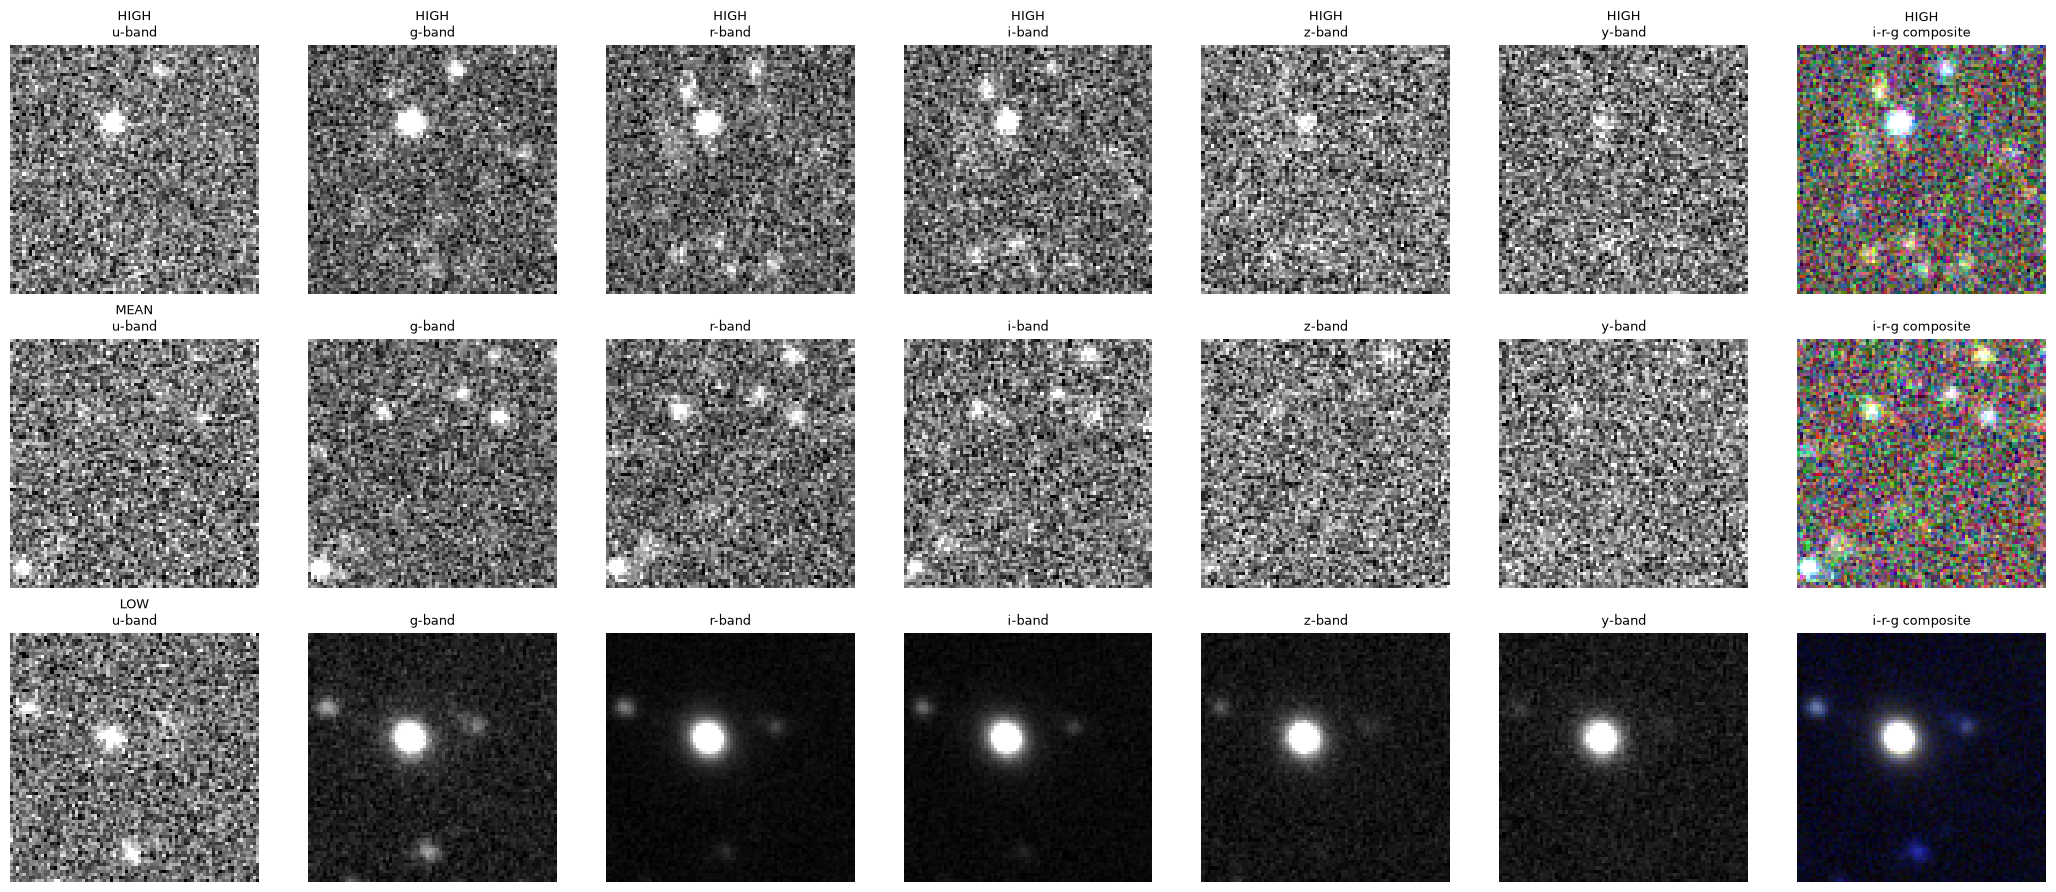


Saved visualization to processed/tile_sample_check.png


In [2]:
import numpy as np
import random
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# PICK ONE RANDOM TILE FROM EACH TIER, VISUALIZE ALL 6 BANDS
# ============================================================
bands = ['u', 'g', 'r', 'i', 'z', 'y']
tiles_root = Path(r"processed/TILES")
tiers = ["HIGH", "MEAN", "LOW"]

random.seed()  # remove/seed a fixed number if you want reproducible picks

selected = {}
for tier in tiers:
    tier_dir = tiles_root / tier
    all_tiles = list(tier_dir.rglob("*.npy"))
    if not all_tiles:
        print(f"WARNING: no tiles found for tier {tier}")
        continue
    chosen = random.choice(all_tiles)
    selected[tier] = chosen
    print(f"{tier}: selected {chosen}")

# ============================================================
# PLOT — one row per tier, one column per band, plus an RGB-ish composite
# ============================================================
n_tiers = len(selected)
fig, axes = plt.subplots(n_tiers, len(bands) + 1, figsize=(3 * (len(bands) + 1), 3 * n_tiers))

if n_tiers == 1:
    axes = axes[np.newaxis, :]

for row, (tier, path) in enumerate(selected.items()):
    tile = np.load(path)  # shape expected: (6, 80, 80)
    print(f"\n{tier} tile shape: {tile.shape}, dtype: {tile.dtype}")
    print(f"  min={tile.min():.3f} max={tile.max():.3f} mean={tile.mean():.3f} "
          f"nan_count={np.isnan(tile).sum()} inf_count={np.isinf(tile).sum()}")

    # per-band panels, each independently scaled so faint structure is visible
    for col, band in enumerate(bands):
        band_img = tile[col]
        vmin, vmax = np.percentile(band_img, [1, 99])
        ax = axes[row, col]
        ax.imshow(band_img, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(f"{tier}\n{band}-band" if row == 0 or col == 0 else f"{band}-band", fontsize=9)
        ax.axis("off")

    # simple pseudo-RGB composite using i, r, g bands (common convention)
    i_idx, r_idx, g_idx = bands.index('i'), bands.index('r'), bands.index('g')
    rgb = np.stack([tile[i_idx], tile[r_idx], tile[g_idx]], axis=-1).astype(np.float32)
    for c in range(3):
        lo, hi = np.percentile(rgb[..., c], [1, 99])
        rgb[..., c] = np.clip((rgb[..., c] - lo) / (hi - lo + 1e-8), 0, 1)
    ax = axes[row, len(bands)]
    ax.imshow(rgb, origin="lower")
    ax.set_title(f"{tier}\ni-r-g composite" if row == 0 else "i-r-g composite", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("processed/tile_sample_check.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved visualization to processed/tile_sample_check.png")

In [3]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.io import fits

# ============================================================
# SHARED SETUP — fresh tiling pass at 59x59, saved channel-last
# for debvader / TensorFlow-format input
# ============================================================
tract_id = "3828"
bands = ['u', 'g', 'r', 'i', 'z', 'y']
tile_size = 59            # <-- changed from 80
image_size = 4100
patch_spacing = 4000      # confirmed empirically: patches are spaced 4000px apart

patch_tiers = {
    "HIGH": ['0,6', '0,0', '1,0', '3,4', '0,2'],
    "MEAN": ['5,0', '5,1', '6,0', '4,1', '4,3'],
    "LOW":  ['2,4', '1,3', '3,1', '6,1', '4,6'],
}

def build_grid_positions(image_size, tile_size):
    positions = list(range(0, image_size - tile_size + 1, tile_size))
    if positions[-1] + tile_size < image_size:
        positions.append(image_size - tile_size)
    return positions

x_positions = build_grid_positions(image_size, tile_size)
y_positions = build_grid_positions(image_size, tile_size)
print(f"Grid: {len(x_positions)} x-positions x {len(y_positions)} y-positions "
      f"= {len(x_positions) * len(y_positions)} cells per patch (tile_size={tile_size})")

catalog = pd.read_parquet(r"processed\cleaned_catalog.parquet")


def process_patch_tf(patch_id, quality_tier):
    raw_images_dir = os.path.join(r"RAW", r"IMAGES", quality_tier)
    tiles_out_dir = Path("processed") / "TILES_TF" / quality_tier / patch_id
    tiles_out_dir.mkdir(parents=True, exist_ok=True)

    print(f"=== PATCH {patch_id} ({quality_tier}) ===")

    # use patch_true — matches the column used for blendedness_truth stratification
    patch_cat = catalog[catalog['patch_true'] == patch_id].copy()
    print(f"Found {len(patch_cat)} total objects in patch {patch_id}.")

    x_raw = patch_cat['x'].values
    y_raw = patch_cat['y'].values

    # --- offset correction (confirmed needed) ---
    patch_col, patch_row = map(int, patch_id.split(','))
    x_offset = patch_col * patch_spacing
    y_offset = patch_row * patch_spacing
    x_coords = x_raw - x_offset
    y_coords = y_raw - y_offset

    if len(x_coords) > 0:
        print(f"x range (corrected): {x_coords.min():.1f} to {x_coords.max():.1f}")
        print(f"y range (corrected): {y_coords.min():.1f} to {y_coords.max():.1f}")

    print(f"Loading FITS images for patch {patch_id} ({quality_tier})...")
    image_data = {}
    for band in bands:
        file_name = f"calexp-{band}-{tract_id}-{patch_id}.fits"
        fits_path = os.path.join(raw_images_dir, band.upper(), file_name)
        with fits.open(fits_path) as hdul:
            image_data[band] = hdul[1].data

    saved_tiles = 0
    discarded_tiles = 0

    for y_min in y_positions:
        for x_min in x_positions:
            x_max = x_min + tile_size
            y_max = y_min + tile_size

            mask = (x_coords >= x_min) & (x_coords < x_max) & \
                   (y_coords >= y_min) & (y_coords < y_max)

            if np.any(mask):
                # stack channel-first first (consistent with raw FITS indexing),
                # then convert to channel-last for TF/debvader
                tile_bands = [image_data[band][y_min:y_max, x_min:x_max] for band in bands]
                stacked_cf = np.stack(tile_bands, axis=0)                  # (6, 59, 59)
                stacked_cf = np.nan_to_num(stacked_cf, nan=0.0, posinf=0.0, neginf=0.0)
                stacked_cl = np.transpose(stacked_cf, (1, 2, 0)).astype(np.float32)  # (59, 59, 6)

                np.save(tiles_out_dir / f"tile_x{x_min}_y{y_min}.npy", stacked_cl)
                saved_tiles += 1
            else:
                discarded_tiles += 1

    print(f"Saved: {saved_tiles} | Discarded: {discarded_tiles} | -> {tiles_out_dir}\n")
    return saved_tiles, discarded_tiles


# ============================================================
# RUN ALL 15 PATCHES
# ============================================================
results = {}
for tier, patch_list in patch_tiers.items():
    for patch_id in patch_list:
        saved, discarded = process_patch_tf(patch_id, tier)
        results[(tier, patch_id)] = (saved, discarded)

print("="*60)
print("SUMMARY")
print("="*60)
total_saved = sum(s for s, d in results.values())
total_discarded = sum(d for s, d in results.values())
for (tier, patch_id), (saved, discarded) in results.items():
    print(f"{tier:5s} {patch_id:6s} saved={saved:5d} discarded={discarded:5d}")
print(f"\nTOTAL saved: {total_saved:,} | TOTAL discarded: {total_discarded:,}")

Grid: 70 x-positions x 70 y-positions = 4900 cells per patch (tile_size=59)
=== PATCH 0,6 (HIGH) ===
Found 2026 total objects in patch 0,6.
x range (corrected): 642.6 to 3995.4
y range (corrected): 0.4 to 3351.0
Loading FITS images for patch 0,6 (HIGH)...
Saved: 1464 | Discarded: 3436 | -> processed\TILES_TF\HIGH\0,6

=== PATCH 0,0 (HIGH) ===
Found 2224 total objects in patch 0,0.
x range (corrected): 863.1 to 3999.3
y range (corrected): 559.0 to 3999.5
Loading FITS images for patch 0,0 (HIGH)...
Saved: 1575 | Discarded: 3325 | -> processed\TILES_TF\HIGH\0,0

=== PATCH 1,0 (HIGH) ===
Found 2703 total objects in patch 1,0.
x range (corrected): 1.3 to 3998.3
y range (corrected): 590.4 to 3999.2
Loading FITS images for patch 1,0 (HIGH)...
Saved: 1944 | Discarded: 2956 | -> processed\TILES_TF\HIGH\1,0

=== PATCH 3,4 (HIGH) ===
Found 2954 total objects in patch 3,4.
x range (corrected): -0.3 to 3999.0
y range (corrected): 2.5 to 3999.5
Loading FITS images for patch 3,4 (HIGH)...
Saved: 2122

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"   

from debvader.model.model import load_deblender

vae_model = load_deblender(
    survey="dc2",
    input_shape=(59, 59, 6),
    latent_dim=32,
    filters=[32, 64, 128, 256],
    kernels=[3, 3, 3, 3],
)

C:\Users\rohit\Downloads\GALAXY_DEBLENDING_DATASET\MODELS\debvader\src\debvader\model\model.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources






in cropping
C:\Users\rohit\Downloads\GALAXY_DEBLENDING_DATASET\MODELS\debvader\src\debvader\data\weights\dc2



In [2]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
BATCH_SIZE = 32
N_EXTREMES = 8          # how many worst/best reconstructions to save as images
output_dir = Path("processed/vae_train_inference")
output_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD MANIFEST, FILTER TO TRAIN SPLIT ONLY
# tile_manifest_tf.parquet -> tiles are ALREADY 59x59x6, channel-last
# (no cropping needed — this is a from-scratch tiling pass, not derived
#  from the 80x80 tiles)
# ============================================================
manifest = pd.read_parquet(r"processed\tile_manifest_tf.parquet")
train_manifest = manifest[manifest["split"] == "train"].reset_index(drop=True)
print(f"Train tiles to process: {len(train_manifest)}")

# ============================================================
# LOAD FUNCTION — straight load, no crop/resize
# ============================================================
def load_tile(tile_path_tf):
    def load_numpy(path):
        arr = np.load(path.numpy().decode("utf-8")).astype(np.float32)
        return arr

    tile = tf.py_function(load_numpy, [tile_path_tf], Tout=tf.float32)
    tile.set_shape([59, 59, 6])
    return tile

# ============================================================
# BUILD DATASET (NO SHUFFLE — order must match train_manifest rows)
# ============================================================
paths = train_manifest["tile_path"].values
dataset = tf.data.Dataset.from_tensor_slices(paths)
dataset = dataset.map(load_tile, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ============================================================
# RUN INFERENCE — METRICS ONLY (no full arrays kept in memory)
# ============================================================
mse_list = []
t0 = time.time()

for i, batch in enumerate(dataset):
    reconstructed = vae_model(batch)
    recon_mean = reconstructed.mean()
    batch_mse = tf.reduce_mean(tf.square(batch - recon_mean), axis=[1, 2, 3]).numpy()
    mse_list.extend(batch_mse.tolist())
    if i % 20 == 0:
        print(f"Batch {i}: processed {min((i+1)*BATCH_SIZE, len(train_manifest))}/{len(train_manifest)}  "
              f"({time.time()-t0:.1f}s elapsed)")

print(f"\nDone in {time.time()-t0:.1f}s")

train_manifest["vae_mse"] = mse_list

# ============================================================
# SAVE METRICS (tied to patch_id / tier / tile_path)
# ============================================================
metrics_out = train_manifest[["tile_path", "patch_id", "tier", "split", "vae_mse"]]
metrics_path = output_dir / "vae_train_metrics.parquet"
metrics_out.to_parquet(metrics_path)
print(f"Saved metrics: {metrics_path}")

# ============================================================
# SUMMARY BY TIER
# ============================================================
print("\nMean VAE reconstruction MSE by tier:")
print(metrics_out.groupby("tier")["vae_mse"].agg(["mean", "median", "std", "count"]))

# ============================================================
# WORST / BEST N — RE-RUN INFERENCE ON JUST THOSE FOR VISUALS
# ============================================================
sorted_idx = np.argsort(mse_list)
best_idx = sorted_idx[:N_EXTREMES]
worst_idx = sorted_idx[-N_EXTREMES:]

def save_examples(indices, label):
    for rank, idx in enumerate(indices):
        row = train_manifest.iloc[idx]
        arr = np.load(row["tile_path"]).astype(np.float32)  # already (59, 59, 6)

        batch = np.expand_dims(arr, axis=0)
        recon = vae_model(batch).mean().numpy()[0]

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(arr[:, :, 2])
        axes[1].imshow(recon[:, :, 2])
        axes[0].set_title(f"Input (tier={row['tier']})")
        axes[1].set_title(f"Reconstructed\nMSE={mse_list[idx]:.4f}")
        axes[0].axis("off")
        axes[1].axis("off")
        plt.tight_layout()

        fname = output_dir / f"{label}_{rank:02d}_idx{idx}_tier{row['tier']}.png"
        fig.savefig(fname, dpi=150, bbox_inches="tight")
        plt.close(fig)

save_examples(worst_idx, "worst")
save_examples(best_idx, "best")

print(f"\nSaved {N_EXTREMES} worst and {N_EXTREMES} best reconstruction images to {output_dir}")
print(f"\nOverall train-set mean MSE: {np.mean(mse_list):.6f}")

Train tiles to process: 16875
Batch 0: processed 32/16875  (1.4s elapsed)
Batch 20: processed 672/16875  (11.5s elapsed)
Batch 40: processed 1312/16875  (21.6s elapsed)
Batch 60: processed 1952/16875  (31.7s elapsed)
Batch 80: processed 2592/16875  (42.2s elapsed)
Batch 100: processed 3232/16875  (53.3s elapsed)
Batch 120: processed 3872/16875  (63.2s elapsed)
Batch 140: processed 4512/16875  (72.7s elapsed)
Batch 160: processed 5152/16875  (82.0s elapsed)
Batch 180: processed 5792/16875  (92.5s elapsed)
Batch 200: processed 6432/16875  (101.9s elapsed)
Batch 220: processed 7072/16875  (112.6s elapsed)
Batch 240: processed 7712/16875  (123.0s elapsed)
Batch 260: processed 8352/16875  (133.7s elapsed)
Batch 280: processed 8992/16875  (144.6s elapsed)
Batch 300: processed 9632/16875  (155.1s elapsed)
Batch 320: processed 10272/16875  (165.7s elapsed)
Batch 340: processed 10912/16875  (176.0s elapsed)
Batch 360: processed 11552/16875  (186.8s elapsed)
Batch 380: processed 12192/16875  (19

In [3]:
metrics = pd.read_parquet(r"processed\vae_train_inference\vae_train_metrics.parquet")

for thresh in [1, 10, 100, 500]:
    n = (metrics["vae_mse"] > thresh).sum()
    pct = 100 * n / len(metrics)
    print(f"Tiles with MSE > {thresh}: {n} ({pct:.2f}%)")

worst = metrics.nlargest(20, "vae_mse")
print(worst[["tile_path", "tier", "vae_mse"]])

Tiles with MSE > 1: 742 (4.40%)
Tiles with MSE > 10: 348 (2.06%)
Tiles with MSE > 100: 179 (1.06%)
Tiles with MSE > 500: 109 (0.65%)
                                              tile_path  tier       vae_mse
12880   processed\TILES_TF\MEAN\4,1\tile_x3540_y236.npy  MEAN  33264.226562
4412    processed\TILES_TF\HIGH\3,4\tile_x2537_y118.npy  HIGH  30577.240234
7395     processed\TILES_TF\LOW\1,3\tile_x3953_y590.npy   LOW  30480.755859
16277  processed\TILES_TF\MEAN\6,0\tile_x2655_y3422.npy  MEAN  29296.835938
15274   processed\TILES_TF\MEAN\5,0\tile_x826_y2065.npy  MEAN  28983.419922
360    processed\TILES_TF\HIGH\0,0\tile_x1652_y3245.npy  HIGH  28556.201172
11403     processed\TILES_TF\MEAN\4,1\tile_x0_y3245.npy  MEAN  28374.644531
5127   processed\TILES_TF\HIGH\3,4\tile_x3658_y3599.npy  HIGH  27885.884766
11406     processed\TILES_TF\MEAN\4,1\tile_x0_y3481.npy  MEAN  26093.041016
9842       processed\TILES_TF\LOW\6,1\tile_x0_y3127.npy   LOW  25622.587891
9476     processed\TILES_TF\LOW

In [4]:
import pandas as pd
import numpy as np

catalog = pd.read_parquet(r"processed\cleaned_catalog_with_blendedness_truth.parquet")
metrics = pd.read_parquet(r"processed\vae_train_inference\vae_train_metrics.parquet")
patch_spacing = 4000
tile_size = 59

def assign_tile_blendedness(row):
    patch_id = row["patch_id"]
    # parse x_pos/y_pos back out of the tile filename since metrics_out didn't carry them forward
    fname = Path(row["tile_path"]).stem  # e.g. "tile_x590_y120"
    x_min = int(fname.split("_x")[1].split("_y")[0])
    y_min = int(fname.split("_y")[1])
    x_max, y_max = x_min + tile_size, y_min + tile_size

    patch_col, patch_row = map(int, patch_id.split(","))
    x_offset = patch_col * patch_spacing
    y_offset = patch_row * patch_spacing

    patch_cat = catalog[catalog["patch_true"] == patch_id]
    x_coords = patch_cat["x"].values - x_offset
    y_coords = patch_cat["y"].values - y_offset

    mask = (x_coords >= x_min) & (x_coords < x_max) & (y_coords >= y_min) & (y_coords < y_max)
    if mask.sum() == 0:
        return np.nan, np.nan, 0
    b = patch_cat["blendedness_truth"].values[mask]
    return b.mean(), b.max(), mask.sum()

from pathlib import Path
results = metrics.apply(assign_tile_blendedness, axis=1, result_type="expand")
metrics[["tile_blend_mean", "tile_blend_max", "n_objects"]] = results

metrics.to_parquet(r"processed\vae_train_inference\vae_train_metrics_with_blend.parquet")

# now the actual comparison
print(metrics[["vae_mse", "tile_blend_mean", "tile_blend_max"]].corr())

# bin by blend severity and see if reconstruction gets worse for more-blended tiles
metrics["blend_bin"] = pd.cut(metrics["tile_blend_max"], bins=[0, 0.02, 0.3, 1.0],
                                labels=["unblended", "blended", "severely_blended"])
print(metrics.groupby("blend_bin")["vae_mse"].agg(["mean", "median", "std", "count"]))

                  vae_mse  tile_blend_mean  tile_blend_max
vae_mse          1.000000        -0.000602       -0.003471
tile_blend_mean -0.000602         1.000000        0.921849
tile_blend_max  -0.003471         0.921849        1.000000
                       mean    median          std  count
blend_bin                                                
unblended         42.041215  0.070279   900.334613   4326
blended           59.513766  0.068461  1008.813965  11180
severely_blended  34.658999  0.071638   573.205417   1369


processed\TILES_TF\MEAN\4,1\tile_x3540_y236.npy
  shape=(59, 59, 6) min=-0.750 max=4731.758 mean=19.888 nan=0 inf=0
processed\TILES_TF\HIGH\3,4\tile_x2537_y118.npy
  shape=(59, 59, 6) min=-0.811 max=4017.454 mean=18.885 nan=0 inf=0
processed\TILES_TF\LOW\1,3\tile_x3953_y590.npy
  shape=(59, 59, 6) min=-3.088 max=4817.198 mean=17.588 nan=0 inf=0
processed\TILES_TF\MEAN\6,0\tile_x2655_y3422.npy
  shape=(59, 59, 6) min=-9.998 max=4527.652 mean=19.651 nan=0 inf=0
processed\TILES_TF\MEAN\5,0\tile_x826_y2065.npy
  shape=(59, 59, 6) min=-0.634 max=5578.027 mean=17.378 nan=0 inf=0
processed\TILES_TF\HIGH\0,0\tile_x1652_y3245.npy
  shape=(59, 59, 6) min=-0.631 max=5740.272 mean=19.951 nan=0 inf=0


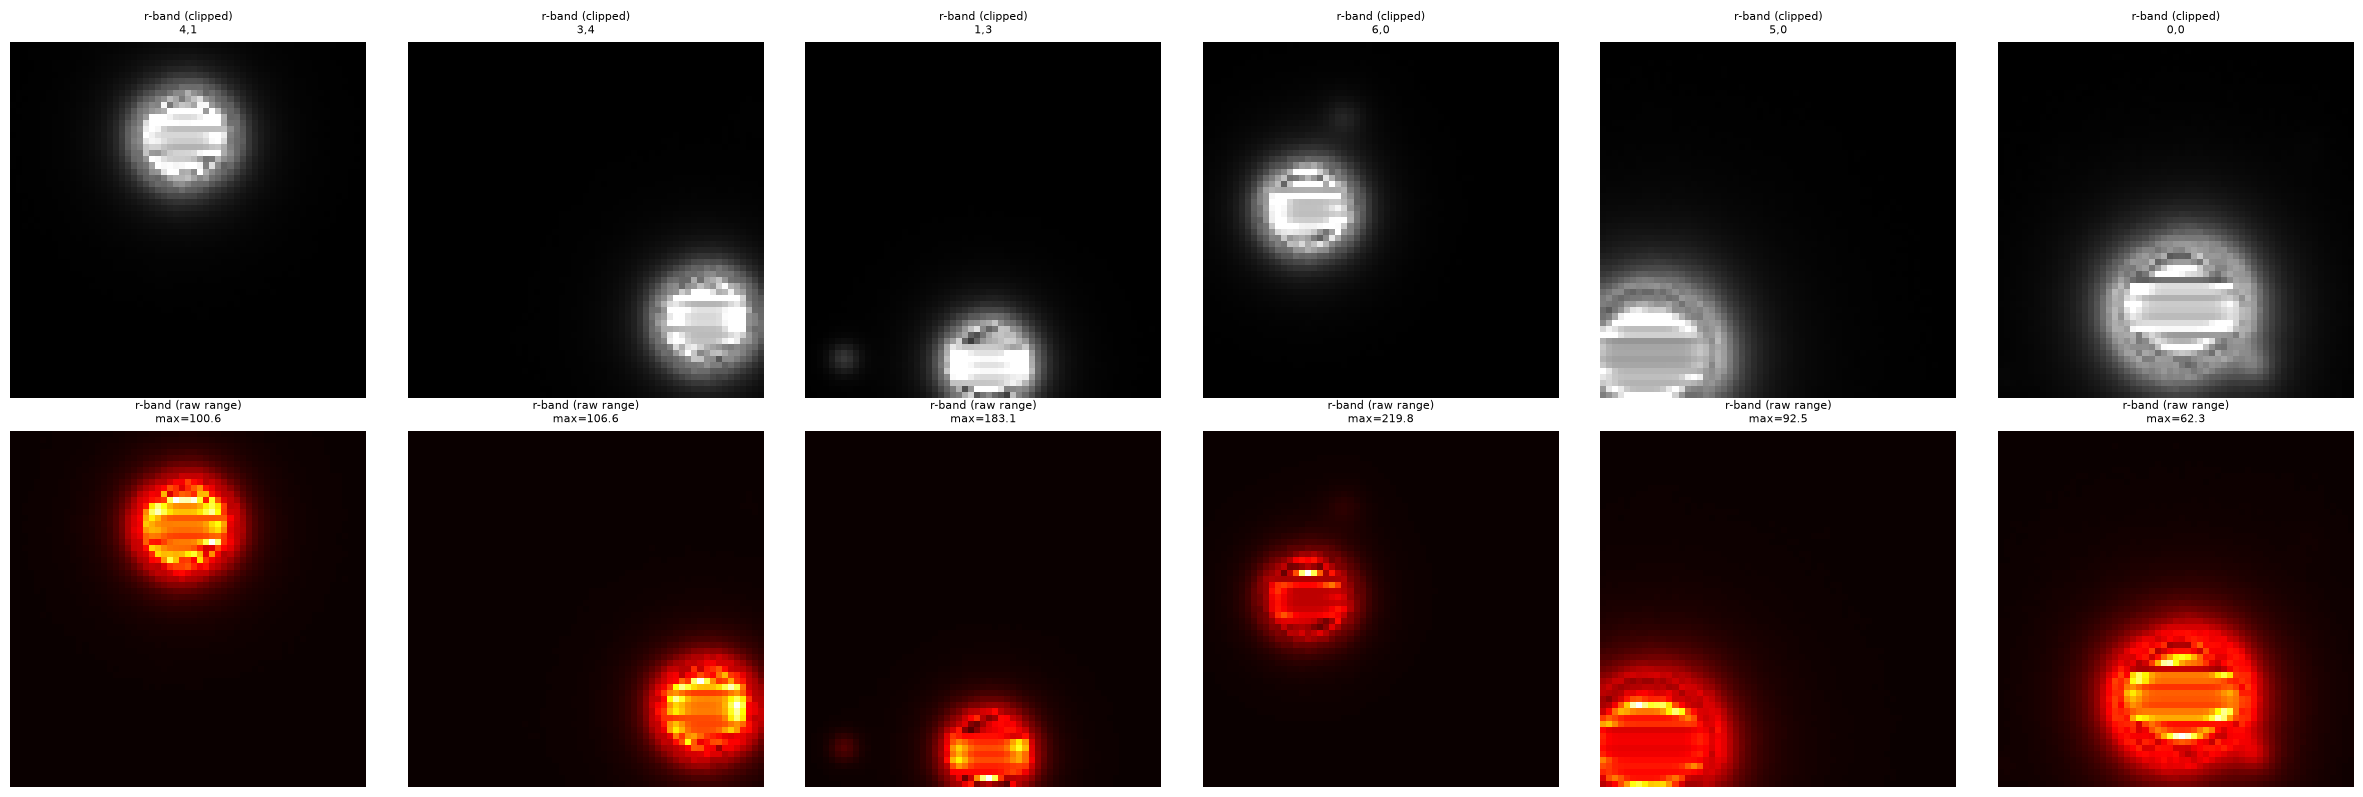

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

worst_paths = [
    r"processed\TILES_TF\MEAN\4,1\tile_x3540_y236.npy",
    r"processed\TILES_TF\HIGH\3,4\tile_x2537_y118.npy",
    r"processed\TILES_TF\LOW\1,3\tile_x3953_y590.npy",
    r"processed\TILES_TF\MEAN\6,0\tile_x2655_y3422.npy",
    r"processed\TILES_TF\MEAN\5,0\tile_x826_y2065.npy",
    r"processed\TILES_TF\HIGH\0,0\tile_x1652_y3245.npy",
]

fig, axes = plt.subplots(2, len(worst_paths), figsize=(4*len(worst_paths), 8))

for col, path in enumerate(worst_paths):
    arr = np.load(path)
    print(f"{path}")
    print(f"  shape={arr.shape} min={arr.min():.3f} max={arr.max():.3f} mean={arr.mean():.3f} "
          f"nan={np.isnan(arr).sum()} inf={np.isinf(arr).sum()}")

    r_band = arr[:, :, 2]  # r-band, index matches your bands list ['u','g','r','i','z','y']
    vmin, vmax = np.percentile(r_band, [1, 99])

    axes[0, col].imshow(r_band, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f"r-band (clipped)\n{Path(path).parent.name}", fontsize=8)
    axes[0, col].axis("off")

    axes[1, col].imshow(r_band, cmap="hot", origin="lower")  # unclipped, full dynamic range
    axes[1, col].set_title(f"r-band (raw range)\nmax={r_band.max():.1f}", fontsize=8)
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig("processed/worst_tiles_inspection.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
import numpy as np

metrics = pd.read_parquet(r"processed\vae_train_inference\vae_train_metrics_with_blend.parquet")

# exclude likely-saturated tiles (same threshold used in your diagnostic: MSE > 500 = 0.65% of tiles)
clean = metrics[metrics["vae_mse"] <= 500].copy()
print(f"Kept {len(clean):,} / {len(metrics):,} tiles after excluding saturation outliers")

# Pearson on cleaned data
print("\nPearson correlation (outliers excluded):")
print(clean[["vae_mse", "tile_blend_mean", "tile_blend_max"]].corr())

# Spearman — rank-based, robust to remaining skew/outliers, often more appropriate here
print("\nSpearman correlation (rank-based, outliers excluded):")
print(clean[["vae_mse", "tile_blend_mean", "tile_blend_max"]].corr(method="spearman"))

# redo the blend-bin breakdown on cleaned data
clean["blend_bin"] = pd.cut(clean["tile_blend_max"], bins=[0, 0.02, 0.3, 1.0],
                              labels=["unblended", "blended", "severely_blended"])
print("\nMSE by blend bin (outliers excluded):")
print(clean.groupby("blend_bin")["vae_mse"].agg(["mean", "median", "std", "count"]))

# save the flag on the full dataset rather than silently dropping rows,
# so saturation cases remain documented/available for your writeup
metrics["likely_saturated"] = metrics["vae_mse"] > 500
metrics.to_parquet(r"processed\vae_train_inference\vae_train_metrics_with_blend.parquet")

Kept 16,766 / 16,875 tiles after excluding saturation outliers

Pearson correlation (outliers excluded):
                  vae_mse  tile_blend_mean  tile_blend_max
vae_mse          1.000000         0.027961        0.021733
tile_blend_mean  0.027961         1.000000        0.921670
tile_blend_max   0.021733         0.921670        1.000000

Spearman correlation (rank-based, outliers excluded):
                  vae_mse  tile_blend_mean  tile_blend_max
vae_mse          1.000000         0.002028        0.005474
tile_blend_mean  0.002028         1.000000        0.983024
tile_blend_max   0.005474         0.983024        1.000000

MSE by blend bin (outliers excluded):
                      mean    median        std  count
blend_bin                                             
unblended         1.277038  0.069697  14.825795   4304
blended           1.399059  0.068004  16.316025  11102
severely_blended  2.335661  0.071392  22.886056   1360


In [7]:
clean = pd.read_parquet(r"processed\vae_train_inference\vae_train_metrics_with_blend.parquet")
clean = clean[clean["vae_mse"] <= 500]

# percentile view per bin instead of mean/median/std alone
clean["blend_bin"] = pd.cut(clean["tile_blend_max"], bins=[0, 0.02, 0.3, 1.0],
                              labels=["unblended", "blended", "severely_blended"])
print(clean.groupby("blend_bin")["vae_mse"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

                    count      mean        std       min       50%       75%  \
blend_bin                                                                      
unblended          4304.0  1.277038  14.825795  0.015507  0.069697  0.114834   
blended           11102.0  1.399059  16.316025  0.015230  0.068004  0.115166   
severely_blended   1360.0  2.335661  22.886056  0.016350  0.071392  0.118868   

                       90%       95%        99%         max  
blend_bin                                                    
unblended         0.221672  0.678002  20.734244  496.025269  
blended           0.205057  0.532151  19.902640  491.765015  
severely_blended  0.237966  0.758537  59.763833  445.755188  


In [8]:
import pandas as pd

catalog = pd.read_parquet(r"processed/cleaned_catalog_with_blendedness_truth.parquet")
patch_spacing = 4000
tile_size = 59

# check one of the worst tiles, e.g. MEAN/4,1/tile_x3540_y236.npy
patch_id = "4,1"
x_min, y_min = 3540, 236
x_max, y_max = x_min + tile_size, y_min + tile_size

patch_col, patch_row = map(int, patch_id.split(","))
x_offset, y_offset = patch_col * patch_spacing, patch_row * patch_spacing

patch_cat = catalog[catalog["patch_true"] == patch_id].copy()
patch_cat["x_local"] = patch_cat["x"] - x_offset
patch_cat["y_local"] = patch_cat["y"] - y_offset

in_tile = patch_cat[
    (patch_cat["x_local"] >= x_min) & (patch_cat["x_local"] < x_max) &
    (patch_cat["y_local"] >= y_min) & (patch_cat["y_local"] < y_max)
]
print(f"Galaxies in this tile: {len(in_tile)}")
print(in_tile[["x_local", "y_local", "mag_r", "blendedness_truth"]])

Galaxies in this tile: 2
           x_local     y_local      mag_r  blendedness_truth
80737  3597.880480  283.984243  21.714647           0.057975
80738  3591.021723  259.578997  24.434000           0.090366


In [1]:
print(truth_full.columns.tolist())
print(truth_full[truth_full["truth_type"] == 2][["ra", "dec", "flux_r"]].describe())

NameError: name 'truth_full' is not defined

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

metrics = pd.read_parquet(r"processed\vae_train_inference\vae_train_metrics_with_blend.parquet")
catalog = pd.read_parquet(r"processed\cleaned_catalog_with_blendedness_truth.parquet")

# flag tiles where a bright star could plausibly be present
# (using the full truth catalog, since stars were filtered OUT of cleaned_catalog)
truth_full = pd.read_parquet(r"raw/truth_match/truth_tract3828.parquet")
stars = truth_full[truth_full["truth_type"] == 2].copy()  # your empirically-confirmed star code

patch_spacing = 4000
tile_size = 59

def has_bright_star_in_tile(row, star_mag_thresh=18.0):
    fname = Path(row["tile_path"]).stem
    x_min = int(fname.split("_x")[1].split("_y")[0])
    y_min = int(fname.split("_y")[1])
    x_max, y_max = x_min + tile_size, y_min + tile_size

    patch_col, patch_row = map(int, row["patch_id"].split(","))
    x_offset, y_offset = patch_col * patch_spacing, patch_row * patch_spacing

    patch_stars = stars[stars["patch"] == row["patch_id"]] if "patch" in stars.columns else stars[stars["patch_true"] == row["patch_id"]]
    sx = patch_stars["ra"] if False else None  # placeholder, see note below
    return None  # see note

print("NOTE: need to confirm star catalog's x/y or ra/dec + patch column names before running this fully")

NOTE: need to confirm star catalog's x/y or ra/dec + patch column names before running this fully


In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import tensorflow as tf
from scipy.optimize import linear_sum_assignment
import sep

# ============================================================
# STEP 0 — CONFIG
# ============================================================
TILE_SIZE = 59
PATCH_SPACING = 4000
MATCH_RADIUS_PX = 1.0          # Duan et al.'s primary threshold
BAND_FOR_DETECTION = 'r'
BAND_IDX = ['u', 'g', 'r', 'i', 'z', 'y'].index(BAND_FOR_DETECTION)
ZEROPOINT = 31.4               # AB mag zeropoint, matches your earlier flux->mag conversions

output_dir = Path("processed/vae_evaluation")
output_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# STEP 1 — RUN VAE ON TEST SPLIT, KEEP RECONSTRUCTED IMAGES
# (previously we only kept MSE — this time we need the actual output pixels)
# ============================================================
manifest = pd.read_parquet(r"processed/tile_manifest_tf.parquet")
test_manifest = manifest[manifest["split"] == "test"].reset_index(drop=True)
print(f"Test tiles: {len(test_manifest)}")

def load_tile(path):
    return np.load(path).astype(np.float32)

recon_records = []
BATCH_SIZE = 32

for start in range(0, len(test_manifest), BATCH_SIZE):
    batch_rows = test_manifest.iloc[start:start + BATCH_SIZE]
    batch_arrs = np.stack([load_tile(p) for p in batch_rows["tile_path"]])
    recon = vae_model(batch_arrs).mean().numpy()   # shape (B, 59, 59, 6)

    for i, (_, row) in enumerate(batch_rows.iterrows()):
        recon_records.append({
            "tile_path": row["tile_path"],
            "patch_id": row["patch_id"],
            "tier": row["tier"],
            "input": batch_arrs[i],
            "recon": recon[i],
        })
    if (start // BATCH_SIZE) % 20 == 0:
        print(f"Processed {start + len(batch_rows)}/{len(test_manifest)}")

print(f"Done. {len(recon_records)} reconstructed tiles ready for measurement.")


# ============================================================
# STEP 2 — SOURCE DETECTION + MEASUREMENT ON EACH TILE
# runs on both the INPUT (truth-derived) tile and the RECONSTRUCTED tile,
# in the same band, using the same detection code — apples to apples
# ============================================================
def detect_and_measure(image_2d):
    img = np.ascontiguousarray(image_2d.astype(np.float32))
    bkg = sep.Background(img)
    data_sub = img - bkg
    try:
        objects = sep.extract(data_sub, thresh=1.5, err=bkg.globalrms)
    except Exception:
        return pd.DataFrame(columns=["x", "y", "flux", "mag", "a", "b", "ellipticity"])

    if len(objects) == 0:
        return pd.DataFrame(columns=["x", "y", "flux", "mag", "a", "b", "ellipticity"])

    flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'], 3.0)
    flux = np.clip(flux, 1e-6, None)
    mag = -2.5 * np.log10(flux) + ZEROPOINT
    a, b = objects['a'], objects['b']
    ellipticity = (a - b) / (a + b)

    return pd.DataFrame({
        "x": objects['x'], "y": objects['y'],
        "flux": flux, "mag": mag,
        "a": a, "b": b, "ellipticity": ellipticity
    })

detections = []  # one entry per tile, with both truth-side and recon-side detections
for rec in recon_records:
    truth_det = detect_and_measure(rec["input"][:, :, BAND_IDX])
    recon_det = detect_and_measure(rec["recon"][:, :, BAND_IDX])
    detections.append({
        "tile_path": rec["tile_path"],
        "patch_id": rec["patch_id"],
        "tier": rec["tier"],
        "truth_det": truth_det,
        "recon_det": recon_det,
    })

print(f"Detection complete on {len(detections)} tiles.")


# ============================================================
# STEP 3 — MATCH TRUTH DETECTIONS TO RECON DETECTIONS
# nearest neighbor within MATCH_RADIUS_PX, resolved via Hungarian algorithm
# (same procedure as Duan et al., Section 4.2)
# ============================================================
def match_detections(truth_det, recon_det, radius=MATCH_RADIUS_PX):
    if len(truth_det) == 0 or len(recon_det) == 0:
        return []

    t_xy = truth_det[["x", "y"]].values
    r_xy = recon_det[["x", "y"]].values

    dist = np.linalg.norm(t_xy[:, None, :] - r_xy[None, :, :], axis=2)
    dist_masked = np.where(dist <= radius, dist, 1e6)  # disallow matches beyond radius

    row_ind, col_ind = linear_sum_assignment(dist_masked)

    matches = []
    for ti, ri in zip(row_ind, col_ind):
        if dist_masked[ti, ri] <= radius:
            matches.append((ti, ri))
    return matches


match_records = []
for det in detections:
    matches = match_detections(det["truth_det"], det["recon_det"])
    for ti, ri in matches:
        t_row = det["truth_det"].iloc[ti]
        r_row = det["recon_det"].iloc[ri]
        match_records.append({
            "tile_path": det["tile_path"],
            "patch_id": det["patch_id"],
            "tier": det["tier"],
            "truth_mag": t_row["mag"],
            "recon_mag": r_row["mag"],
            "mag_error": r_row["mag"] - t_row["mag"],
            "truth_ellip": t_row["ellipticity"],
            "recon_ellip": r_row["ellipticity"],
            "ellip_error": r_row["ellipticity"] - t_row["ellipticity"],
        })

    n_truth = len(det["truth_det"])
    n_matched = len(matches)
    # note unmatched truth detections separately (missed by reconstruction = false negatives)
    det["n_truth"] = n_truth
    det["n_matched"] = n_matched

match_df = pd.DataFrame(match_records)
print(f"\nTotal matched detection pairs: {len(match_df):,}")

total_truth = sum(d["n_truth"] for d in detections)
total_matched = sum(d["n_matched"] for d in detections)
print(f"Detection recall (completeness): {total_matched}/{total_truth} = {100*total_matched/max(total_truth,1):.1f}%")


# ============================================================
# STEP 4 — ATTACH blendedness_truth PER MATCHED DETECTION
# join by spatial proximity to your catalog (same tile + nearest catalog object)
# ============================================================
catalog = pd.read_parquet(r"processed/cleaned_catalog_with_blendedness_truth.parquet")

def attach_blendedness(row):
    fname = Path(row["tile_path"]).stem
    x_min = int(fname.split("_x")[1].split("_y")[0])
    y_min = int(fname.split("_y")[1])

    patch_col, patch_row = map(int, row["patch_id"].split(","))
    x_offset, y_offset = patch_col * PATCH_SPACING, patch_row * PATCH_SPACING

    patch_cat = catalog[catalog["patch_true"] == row["patch_id"]]
    x_local = patch_cat["x"].values - x_offset - x_min
    y_local = patch_cat["y"].values - y_offset - y_min

    # find nearest catalog object to this detection's local tile position
    truth_x, truth_y = row.get("truth_x", np.nan), row.get("truth_y", np.nan)
    if len(x_local) == 0:
        return np.nan
    dist = np.sqrt((x_local) ** 2 + (y_local) ** 2)
    nearest_idx = np.argmin(dist)
    return patch_cat["blendedness_truth"].values[nearest_idx]

# simpler + faster: merge tile-level average blendedness rather than per-object nearest match
tile_blend = catalog.groupby("patch_true")["blendedness_truth"].mean().to_dict()
match_df["patch_mean_blendedness"] = match_df["patch_id"].map(tile_blend)


# ============================================================
# STEP 5 — RESULTS: STRATIFIED BY blendedness_truth, MEDIAN + PERCENTILES
# (matches Arcelin et al. / Duan et al. reporting convention)
# ============================================================
match_df["blend_bin"] = pd.cut(
    match_df["patch_mean_blendedness"],
    bins=[0, 0.02, 0.3, 1.0],
    labels=["unblended", "blended", "severely_blended"]
)

print("\n=== Magnitude error by blend bin (median ± IQR) ===")
mag_summary = match_df.groupby("blend_bin")["mag_error"].agg(
    median="median",
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    count="count"
)
print(mag_summary)

print("\n=== Ellipticity error by blend bin (median ± IQR) ===")
ellip_summary = match_df.groupby("blend_bin")["ellip_error"].agg(
    median="median",
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    count="count"
)
print(ellip_summary)


# ============================================================
# SAVE
# ============================================================
match_df.to_parquet(output_dir / "vae_detection_matches.parquet", index=False)
print(f"\nSaved: {output_dir / 'vae_detection_matches.parquet'}")
print(f"\nOverall completeness (recall): {100*total_matched/max(total_truth,1):.1f}%")
print(f"Overall median magnitude error: {match_df['mag_error'].median():.4f}")
print(f"Overall median ellipticity error: {match_df['ellip_error'].median():.4f}")

Test tiles: 5135


NameError: name 'vae_model' is not defined

In [1]:
import numpy as np
import pandas as pd

manifest_tf = pd.read_parquet(r"processed/tile_manifest_tf.parquet")
subset = manifest_tf[manifest_tf["split"] == "val"].reset_index(drop=True)

sample_paths = subset["tile_path"].sample(200, random_state=42).tolist()

medians, means, stds = [], [], []
for p in sample_paths:
    arr = np.load(p).astype(np.float32)
    r_band = arr[:, :, 2]  # r-band
    edge_mask = np.ones(r_band.shape, dtype=bool)
    edge_mask[10:-10, 10:-10] = False
    border_pixels = r_band[edge_mask]
    medians.append(np.median(border_pixels))
    means.append(np.mean(border_pixels))
    stds.append(np.std(border_pixels))

print(f"Border-pixel median across {len(sample_paths)} tiles:")
print(f"  mean of medians: {np.mean(medians):.6f}")
print(f"  median of medians: {np.median(medians):.6f}")
print(f"  std of medians: {np.std(medians):.6f}")
print(f"\nBorder-pixel mean across tiles: {np.mean(means):.6f}")
print(f"Border-pixel std (noise level) across tiles: {np.mean(stds):.6f}")

print(f"\nIf median is already << std (noise level), background is ~0 and re-subtracting is unnecessary/harmful.")
print(f"Ratio |median|/std: {abs(np.mean(medians))/np.mean(stds):.4f}  (near 0 = already sky-subtracted)")

Border-pixel median across 200 tiles:
  mean of medians: 0.007450
  median of medians: 0.005303
  std of medians: 0.007420

Border-pixel mean across tiles: 0.034698
Border-pixel std (noise level) across tiles: 0.223630

If median is already << std (noise level), background is ~0 and re-subtracting is unnecessary/harmful.
Ratio |median|/std: 0.0333  (near 0 = already sky-subtracted)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ============================================================
# LOAD RESULTS
# ============================================================
df = pd.read_parquet(r"processed/model_comparison_results/VAE_results_kron_nobkg.parquet")
df = df.dropna(subset=["blendedness_VAE", "blendedness_truth", "blendedness_SCARLET"])
df["blend_bin"] = pd.cut(df["blendedness_truth"], bins=[0, 0.02, 0.3, 1.0],
                          labels=["Unblended", "Blended", "Severely Blended"])

out_dir = Path("processed/figures")
out_dir.mkdir(parents=True, exist_ok=True)


def bootstrap_median_ci(values, n_boot=2000, ci=95):
    values = pd.Series(values).dropna().values
    boot = [np.median(np.random.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    lo, hi = np.percentile(boot, (100-ci)/2), np.percentile(boot, 100-(100-ci)/2)
    return np.median(values), lo, hi


# ============================================================
# FIGURE 1 — Grouped bar chart: median error + 95% CI, VAE vs SCARLET, by tier
# ============================================================
tiers = ["Unblended", "Blended", "Severely Blended"]
vae_meds, vae_los, vae_his = [], [], []
sc_meds, sc_los, sc_his = [], [], []

for t in tiers:
    sub = df[df["blend_bin"] == t]
    vae_err = (sub["blendedness_VAE"] - sub["blendedness_truth"]).abs()
    sc_err = (sub["blendedness_SCARLET"] - sub["blendedness_truth"]).abs()
    m, lo, hi = bootstrap_median_ci(vae_err); vae_meds.append(m); vae_los.append(m-lo); vae_his.append(hi-m)
    m, lo, hi = bootstrap_median_ci(sc_err); sc_meds.append(m); sc_los.append(m-lo); sc_his.append(hi-m)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(tiers))
width = 0.35
ax.bar(x - width/2, vae_meds, width, yerr=[vae_los, vae_his], capsize=5, label="VAE (debvader)", color="#4C72B0")
ax.bar(x + width/2, sc_meds, width, yerr=[sc_los, sc_his], capsize=5, label="SCARLET", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(tiers)
ax.set_ylabel("Median |Blendedness Error| (95% CI)")
ax.set_title("Blendedness Recovery Error by Blend Severity Tier")
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / "fig1_bar_comparison.png", dpi=150)
plt.close()
print("Saved fig1_bar_comparison.png")


# ============================================================
# FIGURE 2 — Histograms: blendedness_truth distribution per tier
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"Unblended": "#55A868", "Blended": "#C44E52", "Severely Blended": "#8172B2"}
for t in tiers:
    sub = df[df["blend_bin"] == t]["blendedness_truth"]
    ax.hist(sub, bins=40, alpha=0.6, label=f"{t} (n={len(sub)})", color=colors[t])
ax.set_xlabel("blendedness_truth")
ax.set_ylabel("Count")
ax.set_title("Distribution of blendedness_truth by Tier")
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / "fig2_histogram_truth.png", dpi=150)
plt.close()
print("Saved fig2_histogram_truth.png")


# ============================================================
# FIGURE 3 — Scatter: predicted vs. true blendedness (VAE and SCARLET side by side)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
sample = df.sample(min(3000, len(df)), random_state=42)  # subsample for plot clarity

axes[0].scatter(sample["blendedness_truth"], sample["blendedness_VAE"], s=4, alpha=0.3, color="#4C72B0")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label="Perfect agreement")
axes[0].set_xlabel("blendedness_truth"); axes[0].set_ylabel("blendedness_VAE")
axes[0].set_title("VAE vs. Truth")
axes[0].legend()

axes[1].scatter(sample["blendedness_truth"], sample["blendedness_SCARLET"], s=4, alpha=0.3, color="#DD8452")
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label="Perfect agreement")
axes[1].set_xlabel("blendedness_truth"); axes[1].set_ylabel("blendedness_SCARLET")
axes[1].set_title("SCARLET vs. Truth")
axes[1].legend()

plt.tight_layout()
plt.savefig(out_dir / "fig3_scatter_comparison.png", dpi=150)
plt.close()
print("Saved fig3_scatter_comparison.png")


# ============================================================
# FIGURE 4 — Tier-agreement "confusion matrix": does each model's OWN
# blendedness value classify objects into the same tier as truth?
# ============================================================
def classify_tier(vals):
    return pd.cut(vals, bins=[0, 0.02, 0.3, 1.0], labels=["Unblended", "Blended", "Severely Blended"])

df["vae_bin"] = classify_tier(df["blendedness_VAE"])
df["scarlet_bin"] = classify_tier(df["blendedness_SCARLET"])

def confusion_counts(true_col, pred_col):
    mat = pd.crosstab(df[true_col], df[pred_col], normalize="index")
    return mat.reindex(index=tiers, columns=tiers, fill_value=0)

vae_cm = confusion_counts("blend_bin", "vae_bin")
sc_cm = confusion_counts("blend_bin", "scarlet_bin")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title in zip(axes, [vae_cm, sc_cm], ["VAE: True Tier vs. Predicted Tier", "SCARLET: True Tier vs. Predicted Tier"]):
    im = ax.imshow(cm.values, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(tiers))); ax.set_xticklabels(tiers, rotation=20)
    ax.set_yticks(range(len(tiers))); ax.set_yticklabels(tiers)
    ax.set_xlabel("Predicted Tier"); ax.set_ylabel("True Tier")
    ax.set_title(title)
    for i in range(len(tiers)):
        for j in range(len(tiers)):
            ax.text(j, i, f"{cm.values[i,j]:.2f}", ha="center", va="center",
                    color="white" if cm.values[i,j] > 0.5 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(out_dir / "fig4_tier_confusion_matrix.png", dpi=150)
plt.close()
print("Saved fig4_tier_confusion_matrix.png")


# ============================================================
# FIGURE 5 — Sample tile images: best/worst VAE reconstructions per tier
# (requires re-loading a few actual tiles — adjust paths as needed)
# ============================================================
sample_tiles = []
for t in tiers:
    sub = df[df["blend_bin"] == t].copy()
    sub["err"] = (sub["blendedness_VAE"] - sub["blendedness_truth"]).abs()
    best = sub.nsmallest(1, "err").iloc[0]
    worst = sub.nlargest(1, "err").iloc[0]
    sample_tiles.append((t, "Best", best))
    sample_tiles.append((t, "Worst", worst))

manifest_tf = pd.read_parquet(r"processed/tile_manifest_tf.parquet")
manifest_lookup = manifest_tf.set_index("object_id")["tile_path"]

fig, axes = plt.subplots(3, 2, figsize=(8, 12))
for idx, (tier, label, row) in enumerate(sample_tiles):
    ax = axes[idx // 2, idx % 2]
    try:
        tile_path = manifest_lookup.loc[row["object_id"]]
        arr = np.load(tile_path)
        r_band = arr[:, :, 2]
        vmin, vmax = np.percentile(r_band, [1, 99])
        ax.imshow(r_band, cmap="gray", vmin=vmin, vmax=vmax, origin="lower")
    except Exception as e:
        ax.text(0.5, 0.5, "unavailable", ha="center")
    ax.set_title(f"{tier} — {label}\nerr={row['blendedness_VAE']-row['blendedness_truth']:.3f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig(out_dir / "fig5_sample_tiles.png", dpi=150)
plt.close()
print("Saved fig5_sample_tiles.png")

print(f"\nAll figures saved to {out_dir}")

Saved fig1_bar_comparison.png
Saved fig2_histogram_truth.png
Saved fig3_scatter_comparison.png
Saved fig4_tier_confusion_matrix.png
Saved fig5_sample_tiles.png

All figures saved to processed\figures


In [3]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
import sep

from debvader.model.model import load_deblender
from debvader.normalize.normalize import normalize_non_linear

# Paths
df_path = Path("processed/model_comparison_results/VAE_results_kron_nobkg.parquet")
manifest_path = Path("processed/tile_manifest_tf.parquet")
out_dir = Path("processed/figures")
out_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(df_path).dropna(subset=["blendedness_VAE", "blendedness_truth"])
manifest = pd.read_parquet(manifest_path).set_index("object_id")

# Load VAE model
vae_model = load_deblender(
    survey="dc2", input_shape=(59, 59, 6), latent_dim=32,
    filters=[32, 64, 128, 256], kernels=[3, 3, 3, 3],
)

def asinh_stretch(img, a=0.05):
    """Applies arcsinh stretch for better dynamic range visualization."""
    return np.arcsinh(img / a)

# ============================================================
# NEW FIGURE 5 — Reconstruction Inspection: Input, VAE, Residual
# ============================================================
sample_ids = []
for tier in ["unblended", "blended", "severely_blended"]:
    sub = df[df["blend_bin"] == tier]
    # Grab 1 median error case per tier
    sub["err"] = (sub["blendedness_VAE"] - sub["blendedness_truth"]).abs()
    med_case = sub.sort_values("err").iloc[len(sub)//2]
    sample_ids.append((tier, med_case["object_id"]))

fig, axes = plt.subplots(len(sample_ids), 3, figsize=(9, 3 * len(sample_ids)))
r_idx = 2

for row_idx, (tier, obj_id) in enumerate(sample_ids):
    tile_path = manifest.loc[obj_id, "tile_path"]
    raw_tile = np.load(tile_path).astype(np.float32)
    norm_tile = normalize_non_linear(np.expand_dims(raw_tile, axis=0))
    
    # Run VAE inference
    recon_norm = vae_model(tf.cast(norm_tile, tf.float32), training=False).mean().numpy()[0]
    
    # Unscale r-band
    raw_r = raw_tile[:, :, r_idx]
    recon_r = np.sinh(np.arctanh(np.clip(recon_norm[:, :, r_idx], -0.99, 0.99)))
    residual = np.abs(raw_r - recon_r)
    
    # Plot Raw Input
    ax_in = axes[row_idx, 0]
    ax_in.imshow(asinh_stretch(raw_r), cmap="inferno", origin="lower")
    ax_in.set_title(f"Input ({tier})\nObj ID: {obj_id}", fontsize=9)
    ax_in.axis("off")
    
    # Plot VAE Reconstruction
    ax_rec = axes[row_idx, 1]
    ax_rec.imshow(asinh_stretch(recon_r), cmap="inferno", origin="lower")
    ax_rec.set_title(f"VAE Reconstruction\nBlend Err: {df.loc[df['object_id']==obj_id, 'blendedness_VAE'].values[0] - df.loc[df['object_id']==obj_id, 'blendedness_truth'].values[0]:.3f}", fontsize=9)
    ax_rec.axis("off")
    
    # Plot Residual Map
    ax_res = axes[row_idx, 2]
    im_res = ax_res.imshow(asinh_stretch(residual), cmap="magma", origin="lower")
    ax_res.set_title("Absolute Residual\n|Input - VAE|", fontsize=9)
    ax_res.axis("off")
    plt.colorbar(im_res, ax=ax_res, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(out_dir / "fig5_reconstruction_residuals.png", dpi=200)
plt.close()
print("Saved upgraded fig5_reconstruction_residuals.png")


# ============================================================
# NEW FIGURE 6 — Radial Surface Brightness Profiles
# ============================================================
def get_radial_profile(img, cx=29, cy=29, max_r=25):
    y, x = np.indices(img.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    r_int = r.astype(int)
    radial_mean = [np.mean(img[r_int == i]) for i in range(max_r)]
    return np.arange(max_r), radial_mean

fig, ax = plt.subplots(figsize=(7, 4.5))

for tier, color in zip(["unblended", "blended", "severely_blended"], ["#55A868", "#C44E52", "#8172B2"]):
    sub = df[df["blend_bin"] == tier]
    sample_obj = sub.iloc[0]["object_id"]
    tile_path = manifest.loc[sample_obj, "tile_path"]
    
    raw_tile = np.load(tile_path).astype(np.float32)
    norm_tile = normalize_non_linear(np.expand_dims(raw_tile, axis=0))
    recon_norm = vae_model(tf.cast(norm_tile, tf.float32), training=False).mean().numpy()[0]
    
    raw_r = raw_tile[:, :, r_idx]
    recon_r = np.sinh(np.arctanh(np.clip(recon_norm[:, :, r_idx], -0.99, 0.99)))
    
    radii, raw_prof = get_radial_profile(raw_r)
    _, recon_prof = get_radial_profile(recon_r)
    
    ax.plot(radii, raw_prof, label=f"Raw ({tier})", linestyle="--", color=color, alpha=0.7)
    ax.plot(radii, recon_prof, label=f"VAE ({tier})", linestyle="-", color=color, lw=2)

ax.set_yscale("log")
ax.set_xlabel("Radius from Center (pixels)")
ax.set_ylabel("Mean Pixel Intensity (Log Scale)")
ax.set_title("1D Radial Surface Brightness Profile Recovery")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(out_dir / "fig6_radial_profiles.png", dpi=150)
plt.close()
print("Saved fig6_radial_profiles.png")

C:\Users\rohit\Downloads\GALAXY_DEBLENDING_DATASET\MODELS\debvader\src\debvader\model\model.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources






in cropping
C:\Users\rohit\Downloads\GALAXY_DEBLENDING_DATASET\MODELS\debvader\src\debvader\data\weights\dc2

Saved upgraded fig5_reconstruction_residuals.png
Saved fig6_radial_profiles.png


In [4]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf

from debvader.model.model import load_deblender
from debvader.normalize.normalize import normalize_non_linear

# ---- PATHS & SETUP ----
df_path = Path("processed/model_comparison_results/VAE_results_kron_nobkg.parquet")
manifest_path = Path("processed/tile_manifest_tf.parquet")
out_dir = Path("processed/figures/galleries")
out_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(df_path).dropna(subset=["blendedness_VAE", "blendedness_truth"])
manifest = pd.read_parquet(manifest_path).set_index("object_id")

# Absolute error metric
df["abs_err"] = (df["blendedness_VAE"] - df["blendedness_truth"]).abs()
df["raw_err"] = df["blendedness_VAE"] - df["blendedness_truth"]

# Load pre-trained VAE
vae_model = load_deblender(
    survey="dc2", input_shape=(59, 59, 6), latent_dim=32,
    filters=[32, 64, 128, 256], kernels=[3, 3, 3, 3],
)

def asinh_stretch(img, a=0.05):
    """Applies arcsinh scaling for low-surface-brightness visibility."""
    return np.arcsinh(img / a)

r_idx = 2  # r-band index

# ---- GENERATE GALLERIES FOR EACH TIER AND EXTREME ----
tiers = ["unblended", "blended", "severely_blended"]

for tier in tiers:
    sub = df[df["blend_bin"] == tier].copy()
    
    # Extract top 16 best and worst
    top16_best = sub.nsmallest(16, "abs_err")
    top16_worst = sub.nlargest(16, "abs_err")
    
    for category, sample_df in [("Best", top16_best), ("Worst", top16_worst)]:
        obj_ids = sample_df["object_id"].tolist()
        
        # 1. Batch Load & Process Tiles
        tile_paths = [manifest.loc[oid, "tile_path"] for oid in obj_ids]
        raw_tiles = np.stack([np.load(p).astype(np.float32) for p in tile_paths])
        norm_tiles = normalize_non_linear(raw_tiles)
        
        # 2. Batch VAE Inference
        recon_norms = vae_model(tf.cast(norm_tiles, tf.float32), training=False).mean().numpy()
        
        # 3. Unscale r-band
        raw_r = raw_tiles[:, :, :, r_idx]
        recon_r = np.sinh(np.arctanh(np.clip(recon_norms[:, :, :, r_idx], -0.99, 0.99)))
        residuals = np.abs(raw_r - recon_r)
        
        # 4. Plot 8x6 Grid (8 rows, 2 objects per row)
        fig, axes = plt.subplots(8, 6, figsize=(14, 18))
        fig.suptitle(f"Top 16 {category} Cases — Tier: {tier.upper()}", fontsize=14, y=0.995, fontweight="bold")
        
        for i in range(16):
            r = i // 2       # Row index (0 to 7)
            c_off = (i % 2) * 3  # Column offset (0 or 3)
            
            oid = obj_ids[i]
            row_meta = sample_df.iloc[i]
            err_val = row_meta["raw_err"]
            truth_val = row_meta["blendedness_truth"]
            vae_val = row_meta["blendedness_VAE"]
            
            # Input Stamp
            ax_in = axes[r, c_off]
            ax_in.imshow(asinh_stretch(raw_r[i]), cmap="inferno", origin="lower")
            ax_in.set_title(f"Truth B={truth_val:.2f}", fontsize=7)
            ax_in.axis("off")
            
            # VAE Recon
            ax_rec = axes[r, c_off + 1]
            ax_rec.imshow(asinh_stretch(recon_r[i]), cmap="inferno", origin="lower")
            ax_rec.set_title(f"VAE B={vae_val:.2f}", fontsize=7)
            ax_rec.axis("off")
            
            # Residual
            ax_res = axes[r, c_off + 2]
            ax_res.imshow(asinh_stretch(residuals[i]), cmap="magma", origin="lower")
            ax_res.set_title(f"Err={err_val:+.3f}", fontsize=7, color="crimson" if category=="Worst" else "green")
            ax_res.axis("off")
        
        plt.tight_layout()
        save_path = out_dir / f"gallery_{tier}_{category.lower()}16.png"
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.close()
        print(f"Saved: {save_path}")

in cropping
C:\Users\rohit\Downloads\GALAXY_DEBLENDING_DATASET\MODELS\debvader\src\debvader\data\weights\dc2
Saved: processed\figures\galleries\gallery_unblended_best16.png
Saved: processed\figures\galleries\gallery_unblended_worst16.png
Saved: processed\figures\galleries\gallery_blended_best16.png
Saved: processed\figures\galleries\gallery_blended_worst16.png
Saved: processed\figures\galleries\gallery_severely_blended_best16.png
Saved: processed\figures\galleries\gallery_severely_blended_worst16.png
